# Debate Platform — Persuasion Analysis

This notebook answers: **does AI personality (firm / balanced / open) produce different magnitudes of belief change in human participants compared with human-human debates?**

## Read This First

Use this notebook in order from top to bottom. Later sections depend on tables built earlier.

Quick map:
1. Build clean analysis tables (`debate_df`, `bh_analysis`, `arg_df`, `ref_df`)
2. Estimate inferential models (2-level contrast + 4-level LME)
3. Test moderation and mediation
4. Build ML features and train predictive baselines

What to read first if you are new:
- Section 2 for inclusion/exclusion logic
- Section 9 for the primary human-vs-AI contrast
- Section 10 for the full `condition`-level trajectory model
- Section 12 for mechanism testing (reflection-mediated pathway)

Sections:
1. **Data Loading** - four `condition` levels (human-human, firm, balanced, open-minded)
2. **Data Quality & Exclusion** - completed debates with valid per-round belief records
3. **Debate-Level DataFrame** - one row per debate
4. **Per-Round Belief Change** - delta belief per round
5. **Arguments** - one row per debate turn with argument-level features
6. **Reflections** - one row per between-round paraphrase
7. **Exploratory Data Analysis** - belief trajectories, distributions, summary stats
8. **Stance Change Analysis** - debate-level flip rates and pre/post belief scatter
9. **Human-AI Mode Contrast** - 2-level (human vs AI pooled) LME and logistic, with effect sizes
10. **Statistical Analysis** - 4-level `condition` x round via linear mixed-effects regression
11. **Opponent Identity Assumption & Moderation** - post-debate identity perception as moderator
12. **Reflection Quality & Mediation** - paraphrase quality as mediator of persuasion
13. **ML Feature Construction** - structured features (no leakage across rounds)
14. **ML Models** - Elastic Net and XGBoost predicting per-round belief change

## 0. Research Positioning and Practical Significance

This project treats the live debate platform as both an intervention environment and a data-generation environment. The intervention side asks whether AI debating styles (firm, balanced, open-minded) change human beliefs differently from human-human debates. The data-generation side produces round-level supervision signals (belief updates, confidence, influence, reflections, attribution) for predictive modeling and future policy learning in interactive agents.

The analysis pipeline is designed to support defensible inference before optimization. It prioritizes no-leakage feature construction, role-consistent argument attribution (`arg_player_role`), controlled covariates (`n_rounds`, `first_player_p1`, pre-debate openness), and grouped validation by debate. This ensures observed effects are less likely to be artifacts of round structure, topic mix, or assignment imbalance.

The practical objective is not persuasion maximization in isolation, but constrained improvement of dialogue policy under quality and safety guardrails. Supervised models estimate expected belief movement and identify mechanism signals (for example, reflection fidelity), while later policy optimization can use these signals as reward components with constraints on transparency, non-coercion, and user agency.

This framing generalizes across domains by separating strategy from content: invariant interaction features (turn dynamics, confidence trajectories, reflection fidelity) can be shared, while domain-specific adapters handle legal, support, or software-engineering norms. In governance terms, the work operationalizes measurable influence indicators and audit-ready evaluation procedures for high-impact conversational AI systems.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="Set2")

base_dir = Path.cwd()
output_dir = base_dir / "outputs"
output_dir.mkdir(exist_ok=True)

## 1. Data Loading

Load the four `condition` files and parse the raw JSON into per-condition record lists.

| `condition` | File | Description |
|-----------|------|-------------|
| `human-human` | `human-human.json` | Control — both participants are human |
| `firm` | `firm-debater.json` | AI configured as firm/stubborn debater |
| `balanced` | `balanced-debater.json` | AI configured as balanced debater |
| `open-minded` | `open-debater.json` | AI configured as open-minded debater |

 > **Why four separate files?** Each file corresponds to one between-subjects `condition` level. Keeping them separate at load time makes it trivial to add, remove, or relabel conditions without touching analysis logic downstream.

In [ ]:
SOURCES = {
    "human-human": "human-human.json",
    "firm":        "firm-debater.json",
    "balanced":    "balanced-debater.json",
    "open-minded": "open-debater.json",
}

CONDITION_ORDER = ["human-human", "firm", "balanced", "open-minded"]
CONDITION_LABELS = {
    "human-human": "Human–Human",
    "firm":        "Firm AI",
    "balanced":    "Balanced AI",
    "open-minded": "Open-Minded AI",
}

def load_records(path: Path) -> list:
    with path.open(encoding="utf-8") as f:
        d = json.load(f)
    return [d] if isinstance(d, dict) else d

raw: dict = {
    label: load_records(base_dir / fname)
    for label, fname in SOURCES.items()
}

for label, recs in raw.items():
    print(f"  {label:20s}: {len(recs):>3d} records")

  human-human         :  21 records
  firm                :  28 records
  balanced            :  20 records
  open                :  21 records


## 2. Data Quality & Exclusion Criteria

Debates are excluded if any of the following apply:
- `status != "completed"` — debate was abandoned before completion
- `beliefHistory` for player1 has fewer than 2 entries — no post-round belief checks recorded
- `beliefHistory` round numbers are not monotonically increasing — inconsistent round sequencing

> **Why these criteria?** The unit of analysis is Δbelief per round, so a minimum of two belief readings (round 0 baseline + at least one post-round reading) is required to compute even one observation. Non-monotonic round numbers indicate a backend sequencing error that would produce negative Δbelief artefacts unrelated to persuasion. Abandoned debates offer no post-debate survey and truncated belief series — including them would introduce survivorship bias.

**Round 0 imputation**: 31 records across all four condition files were missing a round 0 `beliefHistory` entry (the pre-debate baseline). These have been imputed directly into the source JSON files using the `preDebateSurvey.player1` × `player1StanceChoice` mapping derived empirically from the 59 records that *do* have round 0:

| `preDebateSurvey.player1` | `player1StanceChoice` | Imputed `beliefValue` |
|---|---|---|
| `open_to_change` | any | 50 |
| `convinced_of_stance` | `for` | 75 |
| `convinced_of_stance` | `against` | 25 |
| `firm_on_stance` | `for` | 100 |
| `firm_on_stance` | `against` | 0 |
| any | `unsure` | 50 |

> **Why this mapping?** The mapping is fully determined by the 59 observed round 0 entries — zero variance within any (pre-survey, stance) cell. It reflects the 0–100 belief scale semantics: "firm on stance" sits at the extreme (0 or 100), "convinced" one step in (25 or 75), and "open to change" always at the neutral midpoint (50). Imputed entries carry `"imputed": true` for traceability and can be filtered downstream if sensitivity analysis is needed.

All exclusions are reported transparently.

In [3]:
def is_valid(rec: dict) -> bool:
    """Return True if the debate record passes all inclusion criteria."""
    if rec.get("status") != "completed":
        return False
    bh = [e for e in rec.get("beliefHistory", []) if e.get("player") == "player1"]
    if len(bh) < 2:   # need at least pre-debate baseline + round 1
        return False
    rounds = [e["round"] for e in bh]
    return rounds == sorted(rounds)   # consistent round sequencing


filtered: dict = {}
total_dropped = 0

for label, recs in raw.items():
    valid   = [r for r in recs if is_valid(r)]
    dropped = len(recs) - len(valid)
    total_dropped += dropped
    print(f"  {label:20s}: {len(valid):>3d} kept, {dropped:>2d} dropped")
    filtered[label] = valid

n_total = sum(len(v) for v in filtered.values())
print(f"\n  Total kept: {n_total}  |  Total dropped: {total_dropped}")

  human-human         :  21 kept,  0 dropped
  firm                :  28 kept,  0 dropped
  balanced            :  20 kept,  0 dropped
  open                :  21 kept,  0 dropped

  Total kept: 90  |  Total dropped: 0


### 2.1 Condition Labels

Each record carries a **`condition`** label - the experimental category used throughout the code and models:

| `condition` | Meaning | AI personality |
|-------------|---------|----------------|
| `human-human` | Human opponent (control) | - |
| `firm` | AI opponent | Firm / stubborn |
| `balanced` | AI opponent | Balanced |
| `open-minded` | AI opponent | Open-minded |

`condition` is the primary between-subjects factor in all statistical and ML models. **All completed debates are retained** - no balanced sub-sampling is applied. Imbalance (20-28 debates per condition) is handled by the models: the LME uses `condition` as a categorical fixed effect, and ML evaluation uses 5-fold `GroupKFold` grouped by `debate_id`.

 > **Why no sub-sampling?** Discarding valid data to force equal group sizes wastes statistical power - especially critical here where the smallest condition has only 20 debates. The LME and GroupKFold both handle unequal group sizes correctly.

In [4]:
# All completed debates are used — no balanced sub-sampling.
# Condition imbalance (20–28 per group) is handled by the models:
#   - LME: condition as categorical fixed effect
#   - ML:  5-fold GroupKFold grouped by debate_id

for label, recs in filtered.items():
    print(f"  {label:20s}: {len(recs):>3d} debates retained")

n_total = sum(len(v) for v in filtered.values())
print(f"\n  Total: {n_total} debates across {len(filtered)} conditions")

  human-human         :  21 debates retained
  firm                :  28 debates retained
  balanced            :  20 debates retained
  open                :  21 debates retained

  Total: 90 debates across 4 conditions


## 3. Debate-Level DataFrame

Flatten each debate record to one row using `pd.json_normalize`. The `debate_id` column (`_id.$oid`) is the primary key for joining with per-round tables. Only player1 post-debate survey fields are retained for AI-condition debates (player2 is the AI and has no survey responses).

> **Why a separate debate-level table?** Several features (topic, pre-debate survey, AI prompt, post-debate attribution) are constant within a debate — repeating them across every per-round row inflates memory and makes joins error-prone. Keeping them at the correct granularity and joining on demand is cleaner and easier to audit.

In [5]:
DEBATE_KEEP = [
    "_id.$oid", "topicId", "topicQuestion", "gameMode",
    "player1Stance", "player1StanceChoice",
    "player2Type", "player2AIModel",
    "player2Stance", "player2StanceChoice",
    "currentBelief.player1", "currentBeliefValue.player1",
    "currentRound", "firstPlayer",
    "preDebateSurvey.player1",
    "preDebateSurvey.player2",         # real self-report in HH; AI personality in AI conditions
    "postDebateSurvey.player1StanceStrength",
    "postDebateSurvey.player1StanceConfidence",
    "postDebateSurvey.player1OpponentPerception",
    "postDebateSurvey.player1PerceptionConfidence",
    "postDebateSurvey.player1SuspicionTiming",
    "postDebateSurvey.player1DetectionCues",
    "postDebateSurvey.player1AiAwarenessEffect",
    "postDebateSurvey.player1AiAwarenessEffect",
    "postDebateSurvey.player1AiAwarenessJustification",
]

frames = []
for label, recs in filtered.items():
    flat = pd.json_normalize(recs, sep=".")
    flat["condition"] = label
    cols = [c for c in DEBATE_KEEP if c in flat.columns] + ["condition"]
    frames.append(flat[cols])

debate_df = (
    pd.concat(frames, ignore_index=True)
    .rename(columns={"_id.$oid": "debate_id", "topicId": "topic_id"})
)

# ── Derived debate-level covariates ──────────────────────────────────────────
# NOTE: n_rounds is merged in after bh_df is constructed (cell below).

# firstPlayer: who delivers the opening argument.
# May confer a primacy or anchoring advantage; 3:1 imbalance in balanced condition
# makes this a meaningful confounder. Binary-encode as 0/1.
# firstPlayer stores the stance string ("for"/"against") of whoever opens;
# compare against player1StanceChoice to determine if player1 went first.
debate_df["first_player_p1"] = (debate_df["firstPlayer"] == debate_df["player1StanceChoice"]).astype(int)

# preDebateSurvey.player2 is semantically valid only in human-human debates.
# In AI conditions it encodes the AI's assigned personality — a completely different
# quantity. Null it out for AI conditions so it is never inadvertently used as if
# it were a participant self-report.
debate_df["presurvey_p2_hh"] = np.where(
    debate_df["condition"] == "human-human",
    debate_df.get("preDebateSurvey.player2"),
    np.nan,
)

print(f"debate_df: {debate_df.shape[0]} rows × {debate_df.shape[1]} cols")
print(f"  (n_rounds merged in after bh_df is constructed — see cell below)")
print(f"\\nfirstPlayer=player1 rate by condition:")
print(debate_df.groupby("condition")["first_player_p1"].mean().round(2).to_string())
display(debate_df.head(3))


debate_df: 90 rows × 28 cols
  (n_rounds merged in after bh_df is constructed — see cell below)
\nfirstPlayer=player1 rate by condition:
condition
balanced       0.65
firm           0.43
human-human    0.57
open           0.43


,debate_id,topic_id,topicQuestion,gameMode,player1Stance,player1StanceChoice,player2Type,player2AIModel,player2Stance,player2StanceChoice,currentBelief.player1,currentBeliefValue.player1,currentRound,firstPlayer,preDebateSurvey.player1,preDebateSurvey.player2,postDebateSurvey.player1StanceStrength,postDebateSurvey.player1StanceConfidence,postDebateSurvey.player1OpponentPerception,postDebateSurvey.player1PerceptionConfidence,postDebateSurvey.player1SuspicionTiming,postDebateSurvey.player1DetectionCues,postDebateSurvey.player1AiAwarenessEffect,postDebateSurvey.player1AiAwarenessEffect,postDebateSurvey.player1AiAwarenessJustification,condition,first_player_p1,presurvey_p2_hh
0,69b03fd157d1915d7288fc61,2,Does pineapple belong on pizza?,human-human,against,against,human,None,for,for,against,0,5,against,open_to_change,firm_on_stance,6,5.0,human,4.0,round_1_2,"[natural_flow, typos_informal, varied_styles]",NaN,NaN,NaN,human-human,1,firm_on_stance
1,69b01cb372628e22871f4c5f,1,Should we use ChatGPT for homework?,human-human,for,for,human,None,against,against,unsure,35,5,against,firm_on_stance,firm_on_stance,5,3.0,human,3.0,round_1_2,"[natural_flow, typos_informal]",NaN,NaN,NaN,human-human,0,firm_on_stance
2,69affeb8a57f60770a789f20,1,Should we use ChatGPT for homework?,human-human,against,against,human,None,for,for,unsure,50,5,against,open_to_change,open_to_change,5,4.0,human,5.0,round_1_2,[emotional_tone],NaN,NaN,NaN,human-human,1,open_to_change


## 4. Per-Round Belief Change

Explode `beliefHistory` so each row is one player × round observation. For player1 (the human participant), compute:

$$\Delta belief_r = belief_r - belief_{r-1}$$

Round 0 is the pre-debate baseline (no opponent argument seen yet); it is retained for reference but excluded from downstream regression analysis where Δbelief is the outcome.

> **Why Δbelief rather than raw belief_value?** Raw belief is a between-subjects level — two participants can have the same trajectory but different starting points. Δbelief captures *within-participant change* per round, which is the theoretically meaningful persuasion signal. Differencing also removes pre-existing stance strength as a confounder.
>
> **Why `belief_shift` additionally?** `belief_shift` adjusts for stance direction: a "for" participant who moves from 30→60 and an "against" participant who moves from 70→40 are both persuaded by the same amount (30 points toward the opponent's side), but raw Δbelief gives opposite signs. `belief_shift > 0` always means "moved toward opponent's position", enabling cross-condition pooling in stance-adjusted plots.

In [6]:
def expand_belief_history(recs: list, label: str) -> pd.DataFrame:
    rows = []
    for rec in recs:
        debate_id = rec["_id"]["$oid"]
        topic_id  = rec.get("topicId")
        p1_stance = rec.get("player1StanceChoice")
        p2_stance = rec.get("player2StanceChoice")
        for entry in rec.get("beliefHistory", []):
            player = entry.get("player")
            rows.append({
                "debate_id":     debate_id,
                "condition":     label,
                "topic_id":      topic_id,
                "stance_choice": p1_stance if player == "player1" else p2_stance,
                "player":        player,
                "round":         entry.get("round"),
                "belief":        entry.get("belief"),
                "belief_value":  entry.get("beliefValue"),
                "confidence":    entry.get("confidence"),
                "influence":     entry.get("influence"),
                "skipped":       entry.get("skipped", False),
            })
    return pd.DataFrame(rows)


bh_df = pd.concat(
    [expand_belief_history(recs, label) for label, recs in filtered.items()],
    ignore_index=True,
)

# Human participants:
#   - player1 in all conditions (always human)
#   - player2 in human-human condition (also human; AI conditions have no human player2)
bh_p1 = pd.concat([
    bh_df[bh_df["player"] == "player1"],
    bh_df[(bh_df["player"] == "player2") & (bh_df["condition"] == "human-human")],
], ignore_index=True).sort_values(["debate_id", "player", "round"]).copy()

# Group by debate_id AND player so each participant's belief series is independent
bh_p1["delta_belief"] = bh_p1.groupby(["debate_id", "player"])["belief_value"].diff()

# belief_shift: stance-adjusted persuasion score.
# Scale is 0=for, 100=against; baseline = 50 (neutral).
# +1 for "for" starters  → persuaded = belief rises  → positive shift
# -1 for "against" starters → persuaded = belief falls → positive shift
# "unsure" starters are excluded (sign=0).
stance_sign = bh_p1["stance_choice"].map({"for": 1, "against": -1}).fillna(0)
bh_p1["belief_shift"] = (bh_p1["belief_value"] - 50) * stance_sign

# Analysis subset: rounds 1+ (round 0 is pre-debate baseline, delta is NaN)
bh_analysis = bh_p1[bh_p1["round"] > 0].reset_index(drop=True)

print(f"Full belief history rows:              {len(bh_df)}")
print(f"Human participant rows (all rounds):   {len(bh_p1)}")
print(f"Human participant rows (r ≥ 1):        {len(bh_analysis)}")
print(f"\nHuman rows by condition:")
print(bh_p1[bh_p1['round'] == 0].groupby(["condition", "player"]).size().to_string())
display(bh_analysis.head(5))

# ── Merge n_rounds into debate_df (needs bh_df, which is now defined) ─────────
# n_rounds: actual number of argument rounds completed (max round in belief history).
# Debates end by mutual consent so this varies widely (~3–14 rounds).
# Must be a covariate in every model — a 14-round debate has far more persuasion
# exposure than a 3-round debate, irrespective of condition.
_round_counts = (
    bh_df.groupby("debate_id")["round"].max()
    .rename("n_rounds")
    .reset_index()
)
debate_df = debate_df.merge(_round_counts, on="debate_id", how="left")
print(f"\nn_rounds merged into debate_df — distribution by condition:")
print(debate_df.groupby("condition")["n_rounds"].describe().round(1).to_string())


Full belief history rows:              1003
Human participant rows (all rounds):   627
Human participant rows (r ≥ 1):        520

Human rows by condition:
condition    player 
balanced     player1    20
firm         player1    28
human-human  player1    21
             player2    17
open         player1    21


,debate_id,condition,topic_id,stance_choice,player,round,belief,belief_value,confidence,influence,skipped,delta_belief,belief_shift
0,6994323324175dcb5216a88b,open,1,for,player1,1,for,100.0,100.0,8,False,0.0,50.0
1,6994323324175dcb5216a88b,open,1,for,player1,2,for,95.0,100.0,25,False,-5.0,45.0
2,6994323324175dcb5216a88b,open,1,for,player1,3,for,85.0,88.0,47,False,-10.0,35.0
3,6994323324175dcb5216a88b,open,1,for,player1,4,for,76.0,88.0,23,False,-9.0,26.0
4,6994323324175dcb5216a88b,open,1,for,player1,5,for,86.0,94.0,15,False,10.0,36.0



n_rounds merged into debate_df — distribution by condition:
             count  mean  std  min  25%  50%  75%   max
condition                                              
balanced      20.0   5.8  2.4  4.0  4.0  5.0  6.2  13.0
firm          28.0   4.4  0.9  2.0  4.0  4.0  5.0   7.0
human-human   21.0   4.2  0.5  4.0  4.0  4.0  4.0   6.0
open          21.0   5.2  1.5  4.0  4.0  4.0  7.0   8.0


## 5. Arguments

Build `arg_df` from `debateRounds`, capturing per-round argument text, token length, and GPT-4o-mini quality score (1-5 scale). Raw `submitted_by` is preserved, and a derived `arg_player_role` (`player1` / `player2`) identifies who sent each argument across all debate types.

> **Why derive `arg_player_role`?** In AI debates, `submitted_by` cleanly separates human and AI. In human-human debates, both sides are `submitted_by == "human"`, so downstream analyses need a stable speaker-role field to distinguish player1 from player2. Keeping the raw field while deriving `arg_player_role` preserves provenance and makes later own-vs-opponent features consistent across all conditions.

> **Why split by speaker role?** Player1 and player2 arguments are conceptually separate predictors in later analyses. Using a role field avoids conflating who produced the argument with whether the opponent was human or AI.

In [ ]:
def _infer_arg_player_role(arg: dict, rec: dict, label: str) -> str | None:
    submitted_by = arg.get("submittedBy")
    arg_stance = arg.get("stance")
    player1_stance = rec.get("player1Stance")
    player2_stance = rec.get("player2Stance")

    if label != "human-human":
        return "player1" if submitted_by == "human" else "player2"

    if arg_stance == player1_stance and arg_stance != player2_stance:
        return "player1"
    if arg_stance == player2_stance and arg_stance != player1_stance:
        return "player2"
    return None

def expand_arguments(recs: list, label: str) -> pd.DataFrame:
    rows = []
    for rec in recs:
        debate_id = rec["_id"]["$oid"]
        topic_id  = rec.get("topicId")
        for arg in rec.get("arguments", []):
            rows.append({
                "debate_id":       debate_id,
                "condition":       label,
                "topic_id":        topic_id,
                "round":           arg.get("round"),
                "submitted_by":    arg.get("submittedBy"),
                "arg_player_role": _infer_arg_player_role(arg, rec, label),
                "stance":          arg.get("stance"),
                "text":            arg.get("text", ""),
            })
    return pd.DataFrame(rows)

arg_df = pd.concat(
    [expand_arguments(recs, label) for label, recs in filtered.items()],
    ignore_index=True,
)
arg_df["arg_length"] = arg_df["text"].str.split().str.len()

print(f"arg_df: {arg_df.shape[0]} rows × {arg_df.shape[1]} cols")
print(f"\nSubmitted-by breakdown:\n{arg_df['submitted_by'].value_counts()}")
print(f"\nArgument sender role breakdown:\n{arg_df['arg_player_role'].value_counts(dropna=False)}")
print(f"\nMean argument length by arg_player_role:")
display(arg_df.groupby("arg_player_role")["arg_length"].describe().round(1))
display(arg_df.head(3))


arg_df: 906 rows × 8 cols

Submitted-by breakdown:
submitted_by
human    526
ai       380
Name: count, dtype: int64

Mean argument length by submitted_by:


,count,mean,std,min,25%,50%,75%,max
submitted_by,,,,,,,,
ai,380.0,44.3,7.6,16.0,40.0,45.0,50.0,63.0
human,526.0,42.7,25.3,1.0,22.0,37.0,66.0,93.0


,debate_id,condition,topic_id,round,submitted_by,stance,text,arg_length
0,69b03fd157d1915d7288fc61,human-human,2,1,human,against,pineapple should not be on pizza because sweet...,22
1,69b03fd157d1915d7288fc61,human-human,2,1,human,for,although i agree warm pineapples are an accqui...,27
2,69b03fd157d1915d7288fc61,human-human,2,2,human,against,i agree that warm pineapples are an acquired t...,45


## 6. Reflections

Extract player1 post-round reflection text. Compute:
- `reflection_length` - character count (proxy for effort)
- `reflection_quality` - GPT-4o-mini score (1-5) rating faithfulness, specificity, engagement, clarity, and charity

 > **Why include reflections?** Reflections are the only direct behavioural signal of how deeply participants processed each argument. According to *Elaboration Likelihood Model* theory, deeper processing increases attitude change durability. Reflections are therefore a natural candidate mediator between AI argument quality and belief shift.
 >
 > **Why GPT-4o-mini scoring rather than just length?** Length is noisy: a long reflection can be repetitive or off-topic. GPT scoring evaluates *accuracy and depth* of engagement with the opposing argument, which is the construct of theoretical interest. Length is retained as a fallback for robustness comparison.

In [ ]:
def expand_reflections(recs: list, label: str) -> pd.DataFrame:
    rows = []
    for rec in recs:
        debate_id = rec["_id"]["$oid"]
        topic_id = rec.get("topicId")
        for ref in rec.get("reflections", []):
            rows.append({
                "debate_id":       debate_id,
                "condition":       label,
                "topic_id":        topic_id,
                "round":           ref.get("round"),
                "player":          ref.get("player"),
                "paraphrase":      ref.get("paraphrase", ""),
                "acknowledgement": ref.get("acknowledgement"),
            })
    return pd.DataFrame(rows)


ref_df = pd.concat(
    [expand_reflections(recs, label) for label, recs in filtered.items()],
    ignore_index=True,
)
ref_df["reflection_length"] = ref_df["paraphrase"].str.split().str.len()
ref_df["acknowledged"] = ref_df["acknowledgement"].str.lower().isin(["yes", "true", "1"])

print(f"ref_df: {ref_df.shape[0]} rows × {ref_df.shape[1]} cols")
print(f"\nAcknowledgement distribution:\n{ref_df['acknowledgement'].value_counts(dropna=False)}")
display(ref_df.head(3))


ref_df: 495 rows × 9 cols

Acknowledgement distribution:
acknowledgement
no                                     94
No                                     58
                                       45
not really                             40
maybe                                  18
                                       ..
No, death is still inevitable           1
not necessarily, fallacy detected       1
adjusting slightly but remains firm     1
i actually hold this view               1
no, this seems like more homework       1
Name: count, Length: 177, dtype: int64


,debate_id,condition,topic_id,round,player,paraphrase,acknowledgement,reflection_length,acknowledged
0,69b03fd157d1915d7288fc61,human-human,2,1,player2,sweet and savoury food should not mix,no,7,False
1,69b03fd157d1915d7288fc61,human-human,2,1,player1,Consuming warm pineapples is a unique and pers...,no,23,False
2,69b03fd157d1915d7288fc61,human-human,2,2,player2,having pineapple isnt traditional to its heritage,no,7,False


In [1]:
# =============================================================================
# NLP Infrastructure Setup
# =============================================================================
# Shared cache and cost-tracking utilities for argument/reflection quality scoring.
# =============================================================================

import os
import hashlib
import json
from openai import OpenAI
HAS_OPENAI = True


def _load_simple_env(env_path: Path) -> None:
    if not env_path.exists():
        return
    for raw_line in env_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        if key and key not in os.environ:
            os.environ[key] = value


_load_simple_env(base_dir / ".env")
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
if HAS_OPENAI and not OPENAI_API_KEY:
    print("OPENAI_API_KEY not set — NLP scoring disabled. Columns will be NaN.")
    HAS_OPENAI = False

# ---------------------------------------------------------------------------
# Score cache
# ---------------------------------------------------------------------------
_SCORE_CACHE_PATH = output_dir / "scores_cache.json"
_score_cache: dict = {}
if _SCORE_CACHE_PATH.exists():
    _score_cache = json.loads(_SCORE_CACHE_PATH.read_text())
    print(f"Loaded {len(_score_cache)} cached scores from {_SCORE_CACHE_PATH.name}")

# ---------------------------------------------------------------------------
# Cost tracking
# GPT-4o mini pricing (https://openai.com/api/pricing):
#   Input  : $0.150 per 1M tokens
#   Output : $0.600 per 1M tokens
# Costs are persisted across runs so the running total is always accurate.
# ---------------------------------------------------------------------------
_COST_LOG_PATH = output_dir / "api_cost_log.json"
_COST_WARNING_THRESHOLD = 100.0        # USD — warning fires at this cumulative total
_GPT4O_MINI_PRICE = {
    "input_per_1m": 0.150,
    "output_per_1m": 0.600,
}

_cost_log: dict = {"total_usd": 0.0, "input_tokens": 0, "output_tokens": 0, "calls": 0}
if _COST_LOG_PATH.exists():
    try:
        _cost_log = json.loads(_COST_LOG_PATH.read_text())
        print(
            f"Cost log loaded: ${_cost_log['total_usd']:.4f} cumulative across "
            f"{_cost_log['calls']} API calls."
        )
    except Exception:
        pass  # corrupt log — start fresh


def _update_cost(usage) -> float:
    """Accumulate token usage into the cost log; return cost of this call (USD)."""
    inp = getattr(usage, "prompt_tokens", 0) or 0
    out = getattr(usage, "completion_tokens", 0) or 0
    call_cost = (
        inp * _GPT4O_MINI_PRICE["input_per_1m"] / 1_000_000
        + out * _GPT4O_MINI_PRICE["output_per_1m"] / 1_000_000
    )
    _cost_log["input_tokens"] += inp
    _cost_log["output_tokens"] += out
    _cost_log["total_usd"] = round(_cost_log["total_usd"] + call_cost, 6)
    _cost_log["calls"] += 1
    _COST_LOG_PATH.write_text(json.dumps(_cost_log, indent=2))
    if _cost_log["total_usd"] >= _COST_WARNING_THRESHOLD:
        print(
            f"\n⚠️  WARNING: Cumulative API cost has reached "
            f"${_cost_log['total_usd']:.4f}, exceeding the "
            f"${_COST_WARNING_THRESHOLD:.0f} threshold. "
            f"Consider pausing or reviewing usage."
        )
    return call_cost


_client = OpenAI(api_key=OPENAI_API_KEY) if HAS_OPENAI else None
print("NLP infra ready. Run the quality scoring cell next.")

NameError: name 'Path' is not defined

In [ ]:
# =============================================================================
# Argument and Reflection Quality Scoring - context-injected + multi-dimensional
# =============================================================================
# Adds quality columns:
#   - arg_df: argument_evidence_quality, argument_logical_coherence, argument_responsiveness, argument_nuance_concession, argument_clarity, arg_quality
#   - ref_df: reflection_faithfulness, reflection_specificity, reflection_engagement, reflection_clarity, reflection_charity, reflection_quality
# Requires Cell 17 (NLP infra setup).
# =============================================================================

if not HAS_OPENAI:
    print("Quality scoring skipped - OPENAI_API_KEY not set.")
    for _col in ["argument_evidence_quality", "argument_logical_coherence", "argument_responsiveness", "argument_nuance_concession", "argument_clarity", "arg_quality"]:
        arg_df[_col] = float("nan")
    for _col in ["reflection_faithfulness", "reflection_specificity", "reflection_engagement", "reflection_clarity", "reflection_charity", "reflection_quality"]:
        ref_df[_col] = float("nan")
    # Backward-compat aliases used in older outputs/scripts
    arg_df["arg_evidence_quality"] = arg_df["argument_evidence_quality"]
    arg_df["arg_logical_coherence"] = arg_df["argument_logical_coherence"]
    arg_df["arg_responsiveness"] = arg_df["argument_responsiveness"]
    arg_df["arg_nuance_concession"] = arg_df["argument_nuance_concession"]
    arg_df["arg_clarity"] = arg_df["argument_clarity"]
    ref_df["ref_faithfulness"] = ref_df["reflection_faithfulness"]
    ref_df["ref_specificity"] = ref_df["reflection_specificity"]
    ref_df["ref_engagement"] = ref_df["reflection_engagement"]
    ref_df["ref_clarity"] = ref_df["reflection_clarity"]
    ref_df["ref_charity"] = ref_df["reflection_charity"]
else:
    # -- Enrich dataframes with topic question --
    _topic_map = debate_df.set_index("debate_id")["topicQuestion"].to_dict()
    if "topicQuestion" not in arg_df.columns:
        arg_df["topicQuestion"] = arg_df["debate_id"].map(_topic_map).fillna("")
    if "topicQuestion" not in ref_df.columns:
        ref_df["topicQuestion"] = ref_df["debate_id"].map(_topic_map).fillna("")

    # -- Opponent-argument lookup for reflections via player role --
    if "opponent_arg_text" not in ref_df.columns:
        _opp_args = arg_df[["debate_id", "round", "arg_player_role", "text"]].copy()
        _opp_args["player"] = np.where(_opp_args["arg_player_role"] == "player1", "player2", "player1")
        _opp_args = _opp_args.rename(columns={"text": "opponent_arg_text"})[["debate_id", "round", "player", "opponent_arg_text"]]
        ref_df = ref_df.merge(_opp_args, on=["debate_id", "round", "player"], how="left")

    _ARG_SYSTEM = """
You are a strict, neutral debate judge evaluating a single argument in a structured debate.
The debate topic, speaker stance, and round number are provided with the argument.

Score ONLY the intrinsic quality of the argument, not whether you agree with its position.
Do not reward verbosity, rhetorical flourish, or confident tone by themselves.
Ignore minor grammar issues unless they materially reduce clarity.

Score each dimension independently on a 1-5 integer scale:
  evidence_quality  - concrete evidence, examples, citations, or detailed explanation supporting the claim
  logical_coherence - clear claim-reason-support structure, internal consistency, and sound reasoning
  responsiveness    - directly engages with the opponent's prior argument rather than talking past it
  nuance_concession - acknowledges counterpoints, limitations, or conditions; avoids false absolutes
  clarity           - readable, unambiguous, and well-organised; meaning is immediately clear
  overall           - holistic quality integrating all five dimensions above

Anchor descriptions (apply to ALL dimensions equally):
  1 = Very weak: absent, incoherent, or nearly content-free on this dimension
  2 = Weak: present but superficial, vague, or logically thin
  3 = Adequate: serviceable but limited in depth, precision, or completeness
  4 = Strong: clear, developed, and well-executed on this dimension
  5 = Excellent: precise, thorough, compelling, and full marks on this dimension

Return ONLY valid JSON with exactly this schema - no extra keys, no explanation:
{"evidence_quality": <int>, "logical_coherence": <int>, "responsiveness": <int>, "nuance_concession": <int>, "clarity": <int>, "overall": <int>}
""".strip()

    _REF_SYSTEM = """
You are a strict, neutral debate judge evaluating a participant's reflective paraphrase of their opponent's argument in a structured debate.
The debate topic, speaker stance, the opponent's original argument (where available), and the participant's paraphrase are all provided.

Do not assume a paraphrase is accurate merely because it is fluent.
Do not reward verbosity alone.

Score each dimension independently on a 1-5 integer scale:
  faithfulness - accuracy of the paraphrase relative to the original argument
                 (if original is unavailable, score from observable cues in the paraphrase itself)
  specificity  - mentions substantive, concrete points rather than generic filler
  engagement   - captures reasoning, tradeoffs, or mechanisms beyond a surface slogan
  clarity      - understandable and coherent as a summary of another person's view
  charity      - represents the opponent's position fairly without strawmanning
  overall      - holistic quality integrating all five dimensions above

Anchor descriptions (apply to ALL dimensions equally):
  1 = Very weak: absent, dismissive, badly unclear, or obviously incorrect on this dimension
  2 = Weak: present but superficial, distorted, or missing key substance
  3 = Adequate: captures the gist but lacks nuance, precision, or completeness
  4 = Strong: clear, specific, and substantively correct on this dimension
  5 = Excellent: precise, nuanced, charitable, and demonstrates deep understanding

Return ONLY valid JSON with exactly this schema - no extra keys, no explanation:
{"faithfulness": <int>, "specificity": <int>, "engagement": <int>, "clarity": <int>, "charity": <int>, "overall": <int>}
""".strip()

    def _build_argument_prompt(row) -> str:
        topic = str(row.get("topicQuestion", "")).strip() or "Not specified"
        stance = str(row.get("stance", "")).strip() or "Not specified"
        rnd = row.get("round", "?")
        text = str(row.get("text", ""))[:500]
        return (
            f"Topic: {topic}\n"
            f"Speaker stance: {stance}\n"
            f"Round: {rnd}\n\n"
            f"Argument text:\n{text}"
        )

    def _build_reflection_prompt(row) -> str:
        topic = str(row.get("topicQuestion", "")).strip() or "Not specified"
        paraphrase = str(row.get("paraphrase", ""))[:700]
        opp = row.get("opponent_arg_text")
        opp_block = (
            f"Original opponent argument:\n{str(opp)[:500]}"
            if pd.notna(opp) and str(opp).strip()
            else "(Original opponent argument unavailable for this condition.)"
        )
        return (
            f"Topic: {topic}\n\n"
            f"{opp_block}\n\n"
            f"Participant's paraphrase:\n{paraphrase}"
        )

    _ARG_KEYS = ["evidence_quality", "logical_coherence", "responsiveness", "nuance_concession", "clarity", "overall"]
    _REF_KEYS = ["faithfulness", "specificity", "engagement", "clarity", "charity", "overall"]

    def _llm_score_multi(prompt: str, system: str, kind: str, keys: list) -> dict:
        nan_result = {k: float("nan") for k in keys}
        if not isinstance(prompt, str) or not prompt.strip():
            return nan_result
        cache_key = hashlib.md5(f"{kind}:{prompt}".encode()).hexdigest()
        if cache_key in _score_cache:
            cached = _score_cache[cache_key]
            if isinstance(cached, dict):
                return {k: float(cached.get(k, float("nan"))) for k in keys}
        try:
            resp = _client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": system},
                    {"role": "user", "content": prompt},
                ],
                temperature=0,
                max_tokens=80,
            )
            parsed = json.loads(resp.choices[0].message.content)
            result = {k: float(parsed.get(k, float("nan"))) for k in keys}
            _score_cache[cache_key] = result
            _update_cost(resp.usage)
            return result
        except Exception:
            return nan_result

    def _score_series(
        df: pd.DataFrame,
        prompt_builder,
        system: str,
        kind: str,
        label: str,
        keys: list,
    ) -> pd.DataFrame:
        rows, n = [], len(df)
        for i, (_, row) in enumerate(df.iterrows()):
            prompt = prompt_builder(row)
            rows.append(_llm_score_multi(prompt, system, kind, keys))
            if (i + 1) % 25 == 0 or (i + 1) == n:
                print(f"  {label}: {i + 1}/{n}", end="\r")
        print()
        _SCORE_CACHE_PATH.write_text(json.dumps(_score_cache))
        return pd.DataFrame(rows, index=df.index)

    _arg_scores = _score_series(
        arg_df, _build_argument_prompt, _ARG_SYSTEM,
        "argument_quality", "argument quality", _ARG_KEYS,
    )
    arg_df["argument_evidence_quality"] = _arg_scores["evidence_quality"]
    arg_df["argument_logical_coherence"] = _arg_scores["logical_coherence"]
    arg_df["argument_responsiveness"] = _arg_scores["responsiveness"]
    arg_df["argument_nuance_concession"] = _arg_scores["nuance_concession"]
    arg_df["argument_clarity"] = _arg_scores["clarity"]
    arg_df["arg_quality"] = _arg_scores["overall"]

    _ref_scores = _score_series(
        ref_df, _build_reflection_prompt, _REF_SYSTEM,
        "reflection_quality", "reflection quality", _REF_KEYS,
    )
    ref_df["reflection_faithfulness"] = _ref_scores["faithfulness"]
    ref_df["reflection_specificity"] = _ref_scores["specificity"]
    ref_df["reflection_engagement"] = _ref_scores["engagement"]
    ref_df["reflection_clarity"] = _ref_scores["clarity"]
    ref_df["reflection_charity"] = _ref_scores["charity"]
    ref_df["reflection_quality"] = _ref_scores["overall"]

    # Backward-compat aliases used in older outputs/scripts
    arg_df["arg_evidence_quality"] = arg_df["argument_evidence_quality"]
    arg_df["arg_logical_coherence"] = arg_df["argument_logical_coherence"]
    arg_df["arg_responsiveness"] = arg_df["argument_responsiveness"]
    arg_df["arg_nuance_concession"] = arg_df["argument_nuance_concession"]
    arg_df["arg_clarity"] = arg_df["argument_clarity"]
    ref_df["ref_faithfulness"] = ref_df["reflection_faithfulness"]
    ref_df["ref_specificity"] = ref_df["reflection_specificity"]
    ref_df["ref_engagement"] = ref_df["reflection_engagement"]
    ref_df["ref_clarity"] = ref_df["reflection_clarity"]
    ref_df["ref_charity"] = ref_df["reflection_charity"]

    print("\n--- API Cost Summary (cumulative after quality scoring) ---")
    print(f"  Cumulative cost : ${_cost_log['total_usd']:.4f}")
    print(f"  Total API calls : {_cost_log['calls']}")
    print(f"  Input tokens    : {_cost_log['input_tokens']:,}")
    print(f"  Output tokens   : {_cost_log['output_tokens']:,}")
    print()
    _arg_cols = ["argument_evidence_quality", "argument_logical_coherence", "argument_responsiveness", "argument_nuance_concession", "argument_clarity", "arg_quality"]
    _ref_cols = ["reflection_faithfulness", "reflection_specificity", "reflection_engagement", "reflection_clarity", "reflection_charity", "reflection_quality"]
    print("Argument quality (mean scores by arg_player_role):")
    display(arg_df.groupby("arg_player_role")[_arg_cols].mean().round(2))
    print("\nReflection quality (mean scores by player):")
    display(ref_df.groupby("player")[_ref_cols].mean().round(2))

In [73]:
# Check maximum raw text lengths before NLP scoring
print("Argument text lengths:")
arg_lengths = arg_df["text"].fillna("").str.len()
display(arg_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame("n_chars").round(0))
print(f"Max argument chars: {int(arg_lengths.max())}")
print(f"Arguments over 2000 chars: {(arg_lengths > 2000).sum()}")

print("\nReflection text lengths:")
ref_lengths = ref_df["paraphrase"].fillna("").str.len()
display(ref_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame("n_chars").round(0))
print(f"Max reflection chars: {int(ref_lengths.max())}")
print(f"Reflections over 2000 chars: {(ref_lengths > 2000).sum()}")

Argument text lengths:


,n_chars
count,906.0
mean,256.0
std,117.0
min,1.0
50%,263.0
90%,432.0
95%,482.0
99%,500.0
max,500.0


Max argument chars: 500
Arguments over 2000 chars: 0

Reflection text lengths:


,n_chars
count,495.0
mean,84.0
std,81.0
min,1.0
50%,59.0
90%,163.0
95%,222.0
99%,445.0
max,670.0


Max reflection chars: 670
Reflections over 2000 chars: 0


## 7. Exploratory Data Analysis

Four visualisations are produced before any inferential modelling:

1. **7.1a — Average belief trajectory by condition**: mean (± SE) belief value over rounds for each `condition` level. Establishes whether raw belief levels diverge across conditions and whether trajectories are monotone or oscillatory.
2. **7.1b — Stance-adjusted persuasion shift**: rescales belief relative to each participant's starting side (`belief_shift > 0` = persuaded away from own position). Removes the directional confound introduced by the 0-100 scale and makes cross-participant comparisons meaningful regardless of initial stance.
3. **7.2 — Per-round delta belief distributions**: histograms of round-to-round belief change for each condition. Reveals distributional shape - skew, modality, whether zero is the dominant value - that informs whether LME's Gaussian error assumption is reasonable.
4. **7.3 — Confidence and perceived influence over rounds**: tracks how certain participants felt in their stance and how strongly they perceived the opponent as influential across rounds. These are not just "feelings" - they feed directly into the ML feature set and may moderate belief change.

A summary table (7.4) closes with mean, SD, and median Δbelief by condition.

 > **Why EDA before modelling?** Ceiling or floor effects in belief trajectories would call for logistic or Tobit specifications rather than LME. Heavy skew in delta belief would motivate a signed-rank test. The confidence/influence plots flag whether self-reported metacognition tracks actual persuasion - a key validity check before treating these as predictors.

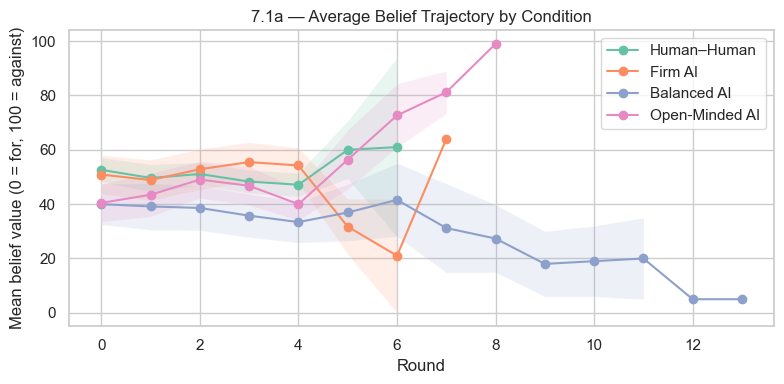

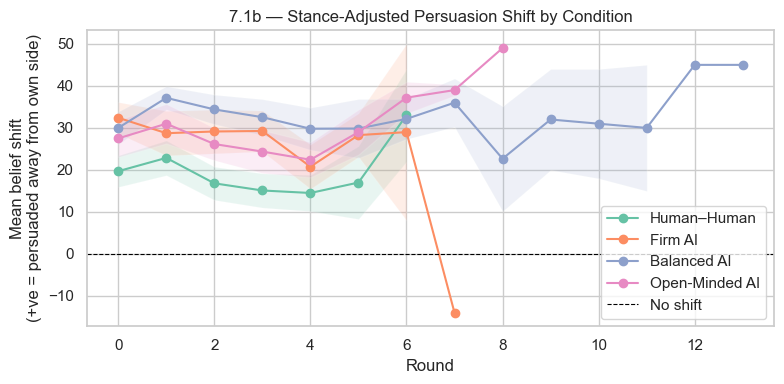

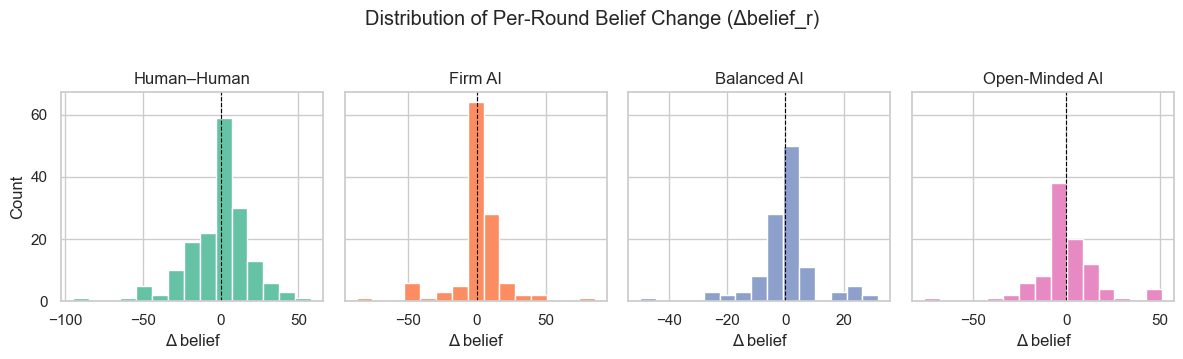

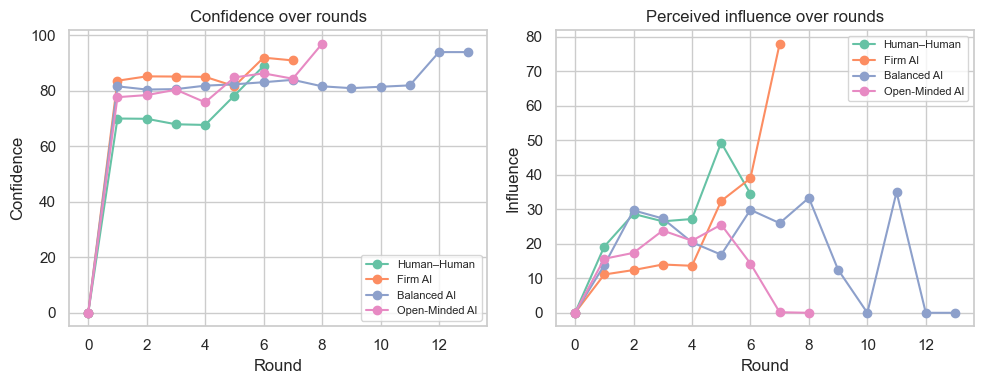

Summary — Δbelief by condition (human participants, rounds 1+):


,n,mean,std,median
condition,,,,
human-human,172,-1.24,20.04,0.0
firm,119,0.40,19.58,0.0
balanced,116,-0.03,10.92,0.0
open,97,0.44,16.84,0.0


In [74]:
# --- 7.1a Average belief trajectory by condition ---
traj = (
    bh_p1.groupby(["condition", "round"])["belief_value"]
    .agg(mean="mean", se=lambda x: x.sem())
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
for cond in CONDITION_ORDER:
    sub = traj[traj["condition"] == cond]
    ax.plot(sub["round"], sub["mean"], marker="o", label=CONDITION_LABELS[cond])
    ax.fill_between(sub["round"],
                    sub["mean"] - sub["se"],
                    sub["mean"] + sub["se"], alpha=0.15)
ax.set_xlabel("Round")
ax.set_ylabel("Mean belief value (0 = for, 100 = against)")
ax.set_title("7.1a — Average Belief Trajectory by Condition")
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "belief_trajectories.png", dpi=150)
plt.show()

# --- 7.1b Stance-adjusted persuasion shift by condition ---
# belief_shift > 0 means the participant moved away from their starting side (persuaded).
# This removes the confound of initial stance direction.
shift_traj = (
    bh_p1[bh_p1["stance_choice"].isin(["for", "against"])]
    .groupby(["condition", "round"])["belief_shift"]
    .agg(mean="mean", se=lambda x: x.sem())
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
for cond in CONDITION_ORDER:
    sub = shift_traj[shift_traj["condition"] == cond]
    ax.plot(sub["round"], sub["mean"], marker="o", label=CONDITION_LABELS[cond])
    ax.fill_between(sub["round"],
                    sub["mean"] - sub["se"],
                    sub["mean"] + sub["se"], alpha=0.15)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8, label="No shift")
ax.set_xlabel("Round")
ax.set_ylabel("Mean belief shift\n(+ve = persuaded away from own side)")
ax.set_title("7.1b — Stance-Adjusted Persuasion Shift by Condition")
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "persuasion_shift_trajectories.png", dpi=150)
plt.show()

# --- 7.2 Δbelief distribution by condition ---
fig, axes = plt.subplots(1, len(CONDITION_ORDER), figsize=(12, 3.5), sharey=True)
for ax, cond in zip(axes, CONDITION_ORDER):
    sub = bh_analysis[bh_analysis["condition"] == cond]["delta_belief"].dropna()
    ax.hist(sub, bins=15, color=sns.color_palette("Set2")[CONDITION_ORDER.index(cond)])
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(CONDITION_LABELS[cond])
    ax.set_xlabel("Δ belief")
axes[0].set_ylabel("Count")
fig.suptitle("Distribution of Per-Round Belief Change (Δbelief_r)", y=1.02)
plt.tight_layout()
plt.savefig(output_dir / "delta_belief_distribution.png", dpi=150)
plt.show()

# --- 7.3 Confidence and perceived influence over rounds ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title in zip(axes,
                          ["confidence", "influence"],
                          ["Confidence over rounds", "Perceived influence over rounds"]):
    for cond in CONDITION_ORDER:
        sub = bh_p1[bh_p1["condition"] == cond].groupby("round")[col].mean()
        ax.plot(sub.index, sub.values, marker="o", label=CONDITION_LABELS[cond])
    ax.set_xlabel("Round")
    ax.set_ylabel(col.capitalize())
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(output_dir / "confidence_influence.png", dpi=150)
plt.show()

# --- 7.4 Summary stats ---
print("Summary — Δbelief by condition (human participants, rounds 1+):")
display(
    bh_analysis.groupby("condition")["delta_belief"]
    .agg(n="count", mean="mean", std="std", median="median")
    .round(2)
    .loc[CONDITION_ORDER]
)

## 8. Stance Change (Flip Analysis)

Binary classify each participant as *flipped* (`flip_label = 1`) if their final belief crossed the midpoint relative to their starting side, or *held* (`flip_label = 0`) otherwise. Compare flip rates across conditions with chi-square and Fischer exact tests.

> **Why the midpoint rule rather than any movement?** A 1-point nudge on a 100-point scale does not constitute a meaningful opinion change. The midpoint (50) represents genuine ambivalence — crossing it means the participant is now nominally on the opponent's side. This threshold is theoretically grounded and insensitive to noise at the extremes.
>
> **Why primarily analyse player1, and when is player2 included?** In the AI conditions (firm, balanced, open-minded), player2 is the AI opponent — it has no genuine pre-debate stance and its "belief trajectory" is artefactual, so it cannot be a persuadee. Restricting to player1 there avoids conflating two different causal roles.
>
> In the **human–human condition**, both players are genuine human persuadees debating against each other. Restricting to player1 alone would throw away half the valid observations. A **dual analysis** is therefore run for human–human: player1 and player2 flip rates are computed separately and then checked for within-debate correlation (are both more likely to flip in the same debate?). If the two players behave symmetrically, their data can be pooled for the human–human baseline flip rate; if they differ (e.g., position assignment creates asymmetry), they are reported separately.
>
> **Why chi-square restricted to AI conditions for the main test?** The primary research question is whether *AI argumentation style* (firm vs balanced vs open-minded) affects flip rate. Adding the human–human condition to a four-way chi-square blurs this question because the manipulation is categorically different (no AI present). Human–human is instead used as a descriptive baseline reference point.

flip_df: 107 participant-debate observations  |  overall flip rate: 43.0%
  (human-human counts both p1 and p2; AI conditions count p1 only)

Flip rate by condition (n = participant-debate observations):


,n_participants,flipped,flip_rate
condition,,,
human-human,38,22.0,0.579
firm,28,12.0,0.429
balanced,20,6.0,0.300
open,21,6.0,0.286



Human-human flip rates by player role:
          n  flipped  flip_rate
player                         
player1  21     11.0      0.524
player2  17     11.0      0.647

Within-debate p1/p2 flip correlation (human-human): r=-0.290, p=0.259
  → No significant within-debate correlation — p1 and p2 can be treated as independent observations.


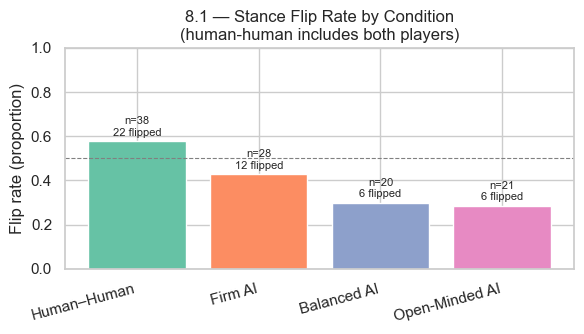

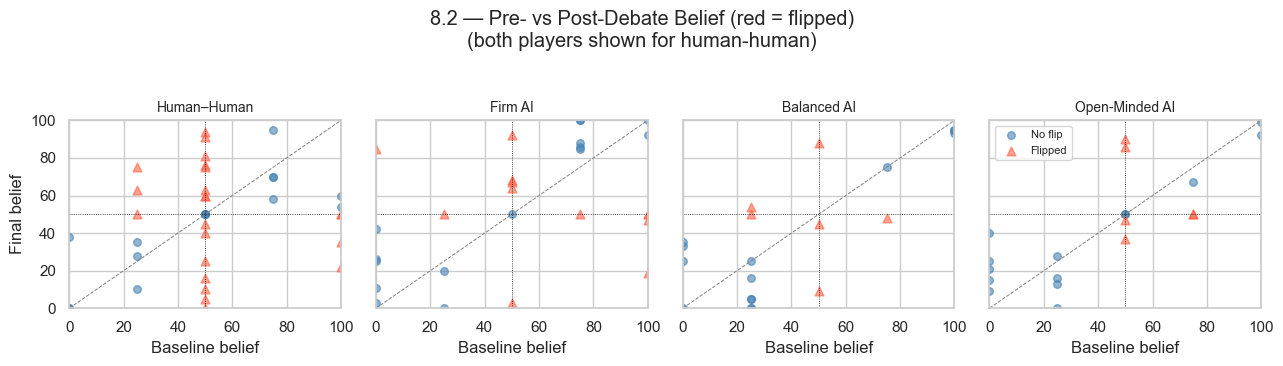


Contingency table (AI conditions, player1 only): flip=1.0 / no-flip=0.0


flip_label,0.0,1.0
condition,,
firm,16,12
balanced,14,6
open,15,6



Chi-square: χ²=1.364, df=2, p=0.506
  → Note: with n≈20/condition the test is underpowered; interpret directionally.


In [10]:
import scipy.stats as _scipy_stats

# ── 8.1 Debate-level stance flip ─────────────────────────────────────────────
# Flip = belief_value crosses midpoint (50) from round 0 to final round.
# bh_p1 contains:
#   - player1 for all 4 conditions (always human)
#   - player2 for human-human only (also human; AI player2 is excluded upstream)
# Group by (debate_id, player) so each participant's series is independent.

def _stance_flip(grp):
    grp = grp.sort_values("round")
    baseline = grp.loc[grp["round"] == 0, "belief_value"]
    final    = grp.loc[grp["round"] > 0,  "belief_value"]
    if baseline.empty or final.empty:
        return {"baseline_belief": float("nan"), "final_belief": float("nan"), "flip_label": float("nan")}
    b = baseline.iloc[0]
    f = final.iloc[-1]
    flipped = int((b < 50 and f >= 50) or (b > 50 and f <= 50) or (b == 50 and f != 50))
    return {"baseline_belief": b, "final_belief": f, "flip_label": float(flipped)}

flip_rows = (
    bh_p1  # both players for human-human; player1 only for AI conditions
    .groupby(["debate_id", "player"])
    .apply(_stance_flip)
    .apply(pd.Series)
    .reset_index()
)

flip_df = flip_rows.merge(
    debate_df[["debate_id", "condition", "topic_id"]],
    on="debate_id", how="left"
)

n_participants = flip_df["flip_label"].notna().sum()
print(f"flip_df: {n_participants} participant-debate observations  |  overall flip rate: {flip_df['flip_label'].mean():.1%}")
print(f"  (human-human counts both p1 and p2; AI conditions count p1 only)\n")

flip_summary = (
    flip_df.groupby("condition")["flip_label"]
    .agg(n_participants="count", flipped="sum", flip_rate="mean")
    .reindex(CONDITION_ORDER)
    .round(3)
)
print("Flip rate by condition (n = participant-debate observations):")
display(flip_summary)

# ── 8.2 Human-human dual-player analysis ──────────────────────────────────────
hh_flip = flip_df[flip_df["condition"] == "human-human"].dropna(subset=["flip_label"])

# Pivot to one row per debate with p1 and p2 flip labels side-by-side
hh_pivot = (
    hh_flip.pivot_table(index="debate_id", columns="player", values="flip_label")
    .dropna()
)

print(f"\nHuman-human flip rates by player role:")
print(hh_flip.groupby("player")["flip_label"].agg(n="count", flipped="sum", flip_rate="mean").round(3).to_string())

# Within-debate correlation: do both players tend to flip (or hold) together?
if len(hh_pivot) >= 3 and "player1" in hh_pivot and "player2" in hh_pivot:
    r_hh, p_hh = _scipy_stats.pearsonr(hh_pivot["player1"], hh_pivot["player2"])
    print(f"\nWithin-debate p1/p2 flip correlation (human-human): r={r_hh:.3f}, p={p_hh:.3f}")
    if p_hh < 0.05:
        print("  → p1 and p2 flips are correlated — debate topic/dynamic drives both; cannot treat as independent.")
    else:
        print("  → No significant within-debate correlation — p1 and p2 can be treated as independent observations.")
else:
    print("\n  (Not enough human-human debates with both players for correlation test)")

# ── 8.3 Bar chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3.5))
palette = sns.color_palette("Set2", len(CONDITION_ORDER))
bars = ax.bar(
    [CONDITION_LABELS[c] for c in CONDITION_ORDER if c in flip_summary.index],
    flip_summary["flip_rate"].values,
    color=palette,
)
for bar, (_, row) in zip(bars, flip_summary.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f"n={int(row['n_participants'])}\n{row['flipped']:.0f} flipped",
            ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Flip rate (proportion)")
ax.set_ylim(0, 1)
ax.set_title("8.1 — Stance Flip Rate by Condition\n(human-human includes both players)")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "stance_flip_rate.png", dpi=150)
plt.show()

# ── 8.4 Pre → post belief scatter ─────────────────────────────────────────────
fig, axes = plt.subplots(1, len(CONDITION_ORDER), figsize=(13, 3.5), sharey=True)
for ax, cond in zip(axes, CONDITION_ORDER):
    sub = flip_df[flip_df["condition"] == cond][["baseline_belief", "final_belief", "flip_label"]].dropna()
    flipped_sub   = sub[sub["flip_label"] == 1]
    unflipped_sub = sub[sub["flip_label"] == 0]
    ax.scatter(unflipped_sub["baseline_belief"], unflipped_sub["final_belief"],
               alpha=0.6, s=30, color="steelblue", label="No flip")
    ax.scatter(flipped_sub["baseline_belief"], flipped_sub["final_belief"],
               alpha=0.6, s=40, color="tomato", marker="^", label="Flipped")
    ax.plot([0, 100], [0, 100], color="grey", linestyle="--", linewidth=0.7)
    ax.axhline(50, color="black", linestyle=":", linewidth=0.6)
    ax.axvline(50, color="black", linestyle=":", linewidth=0.6)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_title(CONDITION_LABELS[cond], fontsize=10)
    ax.set_xlabel("Baseline belief")
axes[0].set_ylabel("Final belief")
axes[-1].legend(fontsize=8)
note = "(both players shown for human-human)"
fig.suptitle(f"8.2 — Pre- vs Post-Debate Belief (red = flipped)\n{note}", y=1.04)
plt.tight_layout()
plt.savefig(output_dir / "belief_pre_post_scatter.png", dpi=150)
plt.show()

# ── 8.5 Chi-square across AI conditions (player1 only — symmetric treatment) ──
ai_flip = flip_df[
    (flip_df["condition"] != "human-human") & (flip_df["player"] == "player1")
].dropna(subset=["flip_label"])
contingency = (
    ai_flip.groupby("condition")["flip_label"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(index=[c for c in CONDITION_ORDER if c != "human-human"])
)
print("\nContingency table (AI conditions, player1 only): flip=1.0 / no-flip=0.0")
display(contingency)
chi2, p, dof, _ = _scipy_stats.chi2_contingency(contingency.values)
print(f"\nChi-square: χ²={chi2:.3f}, df={dof}, p={p:.3f}")
print("  → Note: with n≈20/condition the test is underpowered; interpret directionally.")


## 9. Human-AI Mode Contrast (2-Level)

Before decomposing AI personality differences in Section 10, a coarser 2-level contrast answers the primary research question: **does the presence of an AI opponent - regardless of personality - produce different persuasion outcomes compared with a human opponent?**

All four `condition` levels are collapsed into a binary variable: `ai_mode = 0` (human-human) vs `ai_mode = 1` (firm, balanced, open-minded pooled). Both outcomes mirror the finer-grained analyses that follow:

- **Primary (continuous)**: per-round delta belief modelled by LME with `ai_mode x round_c` interaction, restricted to player1, controlling for `n_rounds`, `first_player_p1`, `presurvey_enc`, and `topic_id`.
- **Secondary (debate-level binary)**: stance-flip probability modelled by logistic regression with the same controls.

Effect sizes are reported with 95% CIs: beta (unstandardised) for the continuous model, odds ratio for the flip model.

 > **Why pool AI conditions rather than extract a grand-mean AI estimate from the 4-level model?** Pooling gives a direct, interpretable contrast against the human baseline with maximum within-AI-pool statistical power. Extracting an "average AI" estimate from the 4-level model requires averaging across unequal-n cells (n approximately 20-28 per AI condition), which weights conditions by sample size rather than conceptual equivalence. The 2-level model is the right tool for this specific question.
 >
 > **Why restrict to player1?** The matching algorithm assigns player2 as the AI opponent in all AI conditions and as another human in human-human. Restricting to player1 ensures every row represents a human persuadee facing either an AI (`ai_mode = 1`) or another human (`ai_mode = 0`), making the contrast symmetric and unconfounded by player role.
 >
 > **Why include `presurvey_enc`?** Pre-debate stance firmness (open_to_change / convinced / firm) captures baseline resistance to persuasion - a participant who begins firmly committed is harder to move regardless of condition. Including it prevents pre-existing differences in firmness from masquerading as a condition effect.

In [76]:
try:
    import statsmodels.formula.api as smf
    import statsmodels.api as sm
    _HAS_SM = True
except ImportError:
    _HAS_SM = False
    print("statsmodels not installed — skipping 2-level contrast models.")

_presurvey_enc_map = {"open_to_change": 0, "convinced_of_stance": 1, "firm_on_stance": 2}

# ── 9.1 Build player1-only dataset with covariates ────────────────────────────
# Player1 is always a human persuadee across all conditions.
# Each debate has exactly one player1 → participant_id == debate_id (no duplicates).
lme_p1 = (
    bh_analysis[bh_analysis["player"] == "player1"]
    .merge(
        debate_df[[
            "debate_id", "topic_id", "n_rounds",
            "first_player_p1", "preDebateSurvey.player1",
        ]],
        on="debate_id", how="left",
    )
    .dropna(subset=["delta_belief", "condition", "round"])
    .copy()
)
lme_p1["ai_mode"]       = (lme_p1["condition"] != "human-human").astype(int)
lme_p1["round_c"]       = lme_p1["round"]    - lme_p1["round"].mean()
lme_p1["n_rounds_c"]    = lme_p1["n_rounds"] - lme_p1["n_rounds"].mean()
lme_p1["presurvey_enc"] = (
    lme_p1["preDebateSurvey.player1"].map(_presurvey_enc_map).fillna(0).astype(int)
)

# ── 9.2 Raw means by mode ─────────────────────────────────────────────────────
print("Raw means — per-round Δbelief by mode (player1 only):")
mode_means = (
    lme_p1.groupby("ai_mode")["delta_belief"]
    .agg(n="count", mean="mean", sd="std", median="median")
    .rename(index={0: "human-human", 1: "AI (pooled)"})
    .round(3)
)
display(mode_means)

# ── 9.3 Primary: LME on per-round Δbelief ─────────────────────────────────────
if _HAS_SM:
    formula_2lvl = (
        "delta_belief ~ ai_mode * round_c"
        " + n_rounds_c + first_player_p1 + presurvey_enc"
        " + C(topic_id)"
    )
    lme_2lvl = smf.mixedlm(
        formula_2lvl,
        data=lme_p1,
        groups=lme_p1["debate_id"],
    ).fit(reml=True, method="lbfgs")

    print("\n--- 9.3 LME: ai_mode × round_c (player1, topic-controlled) ---")
    print(lme_2lvl.summary())

    _ci_2lvl  = lme_2lvl.conf_int()
    coef_2lvl = lme_2lvl.params.get("ai_mode", float("nan"))
    ci_lo_2   = _ci_2lvl.loc["ai_mode", 0] if "ai_mode" in _ci_2lvl.index else float("nan")
    ci_hi_2   = _ci_2lvl.loc["ai_mode", 1] if "ai_mode" in _ci_2lvl.index else float("nan")
    pval_2lvl = lme_2lvl.pvalues.get("ai_mode", float("nan"))
    direction_cont = "higher" if coef_2lvl > 0 else "lower"
    print(f"\nai_mode effect on Δbelief (AI vs human-human):")
    print(f"  β = {coef_2lvl:+.3f}  95% CI [{ci_lo_2:.3f}, {ci_hi_2:.3f}]  p = {pval_2lvl:.3f}")
    print(f"  Per-round belief change is {abs(coef_2lvl):.3f} points {direction_cont} in AI debates,")
    print(f"  controlling for round, n_rounds, first_player, pre-survey, and topic.")
else:
    print("statsmodels not available — skipping LME.")

# ── 9.4 Flip rate by mode ─────────────────────────────────────────────────────
flip_p1 = (
    flip_df[flip_df["player"] == "player1"]
    .dropna(subset=["flip_label"])
    .merge(
        debate_df[[
            "debate_id", "n_rounds", "first_player_p1",
            "preDebateSurvey.player1",
        ]],
        on="debate_id", how="left",
    )
    .copy()
)
flip_p1["ai_mode"]       = (flip_p1["condition"] != "human-human").astype(int)
flip_p1["presurvey_enc"] = (
    flip_p1["preDebateSurvey.player1"].map(_presurvey_enc_map).fillna(0).astype(int)
)

print("\nRaw means — flip rate by mode (player1 only):")
flip_mode = (
    flip_p1.groupby("ai_mode")["flip_label"]
    .agg(n="count", flipped="sum", flip_rate="mean")
    .rename(index={0: "human-human", 1: "AI (pooled)"})
    .round(3)
)
display(flip_mode)

# ── 9.5 Secondary: logistic regression on flip_label ─────────────────────────
if _HAS_SM:
    topic_dummies = pd.get_dummies(flip_p1["topic_id"], prefix="topic", drop_first=True)
    X_log = pd.concat([
        flip_p1[["ai_mode", "first_player_p1", "presurvey_enc"]].reset_index(drop=True),
        topic_dummies.reset_index(drop=True),
    ], axis=1).astype(float)
    X_log = sm.add_constant(X_log)
    y_log = flip_p1["flip_label"].astype(float).reset_index(drop=True)

    logit_2lvl = sm.Logit(y_log, X_log).fit(disp=False)

    _ci_log = logit_2lvl.conf_int()
    ai_b   = logit_2lvl.params.get("ai_mode", float("nan"))
    ai_lo  = _ci_log.loc["ai_mode", 0] if "ai_mode" in _ci_log.index else float("nan")
    ai_hi  = _ci_log.loc["ai_mode", 1] if "ai_mode" in _ci_log.index else float("nan")
    ai_p   = logit_2lvl.pvalues.get("ai_mode", float("nan"))
    direction_or = "higher" if ai_b > 0 else "lower"

    print(f"\n--- 9.5 Logistic regression: ai_mode → flip_label (player1, topic-controlled) ---")
    print(f"  log-odds β = {ai_b:+.3f}  95% CI [{ai_lo:.3f}, {ai_hi:.3f}]  p = {ai_p:.3f}")
    print(f"  OR = {np.exp(ai_b):.3f}  95% CI [{np.exp(ai_lo):.3f}, {np.exp(ai_hi):.3f}]")
    print(f"  Odds of flipping are {np.exp(ai_b):.2f}× {direction_or} in AI debates")
    print(f"  relative to human-human, controlling for first_player, pre-survey, and topic.")
else:
    print("statsmodels not available — skipping logistic regression.")


Raw means — per-round Δbelief by mode (player1 only):


,n,mean,sd,median
ai_mode,,,,
human-human,88,-1.886,22.887,0.0
AI (pooled),332,0.262,16.137,0.0


PatsyError: Error evaluating factor: NameError: name 'topic_id' is not defined
    delta_belief ~ ai_mode * round_c + n_rounds_c + first_player_p1 + presurvey_enc + C(topic_id)
                                                                                      ^^^^^^^^^^^

## 10. Linear Mixed-Effects Model

Fit an LME model with delta belief as the outcome, `condition x round` as the fixed-effect interaction, nuisance covariates, and `participant_id` as the random-intercept grouping factor. `condition` is the between-subjects treatment variable.

$$\Delta belief_{irt} = \beta_0 + \beta_1 \cdot \text{condition}_i + \beta_2 \cdot round_r + \beta_3 \cdot (\text{condition} \times round)_{ir} + \beta_4 \cdot n\_rounds_i + \beta_5 \cdot firstPlayer_i + \beta_6 \cdot topic_t + u_i + \epsilon_{irt}$$

where $u_i \sim \mathcal{N}(0, \sigma^2_{\text{participant}})$.

 > **Why LME over repeated-measures ANOVA or OLS?** Rounds are nested within debates, which are nested within participants. LME explicitly models this hierarchical dependence via the random intercept `(1 | participant_id)`, giving correct standard errors. ANOVA assumes sphericity; OLS ignores clustering - both inflate Type-I error.
 >
 > **Why `condition x round` interaction?** The theoretical question is whether *different condition levels produce different per-round persuasion trajectories*, not just different average levels. The interaction term directly tests whether the effect of round number on belief change differs across condition levels.
 >
 > **Why `n_rounds` as a covariate?** Approximately 95% of debates end by mutual consent, so debate length varies widely (3-14 rounds). A participant in a 14-round debate has accumulated far more argument exposure than one in a 3-round debate - independent of condition. Without this control, condition differences in average round number would confound the treatment effect.
 >
 > **Why `first_player_p1` as a covariate?** Who speaks first may confer a primacy or anchoring advantage. The balanced condition has a 3:1 imbalance in first-player assignment, making it a confounder that could partially explain differences in belief change across condition levels.
 >
 > **Why topic as a fixed covariate rather than a random effect?** Topic is a nuisance variable we want to partial out. Three criteria determine the right treatment:
 >
 > - *Too few levels for a random effect*: only 3 distinct topics are present. A random intercept requires estimating a variance component $\sigma^2_{\text{topic}}$ from 3 groups - the estimate is singular and the optimizer consistently warns of non-convergence. Rule of thumb is at least 5-6 levels minimum; at least 10 for reliable estimation.
 > - *Topics are not a random sample from a population*: topics were selected by participants from a platform menu (not drawn randomly from all possible debate motions), so the random-effects assumption - that levels are i.i.d. draws from $\mathcal{N}(0, \sigma^2_{\text{topic}})$ - does not hold. Inference would not generalise to "all debate topics", only these three.
 > - *Approximate orthogonality guards against self-selection bias*: because participants chose their own topics, topic choice may correlate with participant characteristics (prior conviction, topic familiarity) that also affect persuadability. However, the observed topic x condition cross-tabulation (n approximately 7-13 per cell) shows no systematic confounding between topic preference and assigned condition - deviations from expected counts under independence are small. The topic dummies therefore absorb topic-level variance without biasing the condition estimate. The per-topic coefficients are not interpreted.
 >
 > **Why REML instead of ML?** REML produces unbiased estimates of variance components when fixed effects are present. ML underestimates variance in small samples. REML is the standard estimator for LME when the goal is parameter inference, not model comparison via LRT.

In [ ]:
try:
    import statsmodels.formula.api as smf
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels not installed — skipping mixed-effects models.\n"
          "Install with: pip install statsmodels")

if HAS_STATSMODELS:
    # participant_id is debate_id + player — unique per human in the dataset.
    # For human-human debates two humans share the same debate_id, so grouping
    # by debate_id alone would collapse two independent belief series.
    lme_df = bh_analysis.copy()
    lme_df["participant_id"] = lme_df["debate_id"] + "_" + lme_df["player"]
    lme_df = lme_df.merge(
        debate_df[["debate_id", "topic_id", "n_rounds", "first_player_p1"]],
        on="debate_id", how="left",
    ).dropna(subset=["delta_belief", "condition", "round"])

    lme_df["condition"] = pd.Categorical(
        lme_df["condition"], categories=CONDITION_ORDER, ordered=False
    )
    lme_df["round_c"]    = lme_df["round"]    - lme_df["round"].mean()
    lme_df["n_rounds_c"] = lme_df["n_rounds"] - lme_df["n_rounds"].mean()

    # Covariates:
    #   n_rounds_c     — debate length (centred); debates end by mutual consent so
    #                    a 14-round debate has far more persuasion exposure than a
    #                    3-round one regardless of condition.
    #   first_player_p1 — whether player1 opened; primacy/anchoring effect; 3:1
    #                     imbalance in balanced condition makes this a confounder.
    #   C(topic_id)    — fixed dummies absorb between-topic variance; too few topic
    #                    levels for a stable random effect.
    formula = (
        "delta_belief ~ C(condition, Treatment('human-human')) * round_c"
        " + n_rounds_c"
        " + first_player_p1"
        " + C(topic_id)"
    )

    lme_model = smf.mixedlm(
        formula,
        data=lme_df,
        groups=lme_df["participant_id"],
    )
    lme_result = lme_model.fit(reml=True, method="lbfgs")
    print(lme_result.summary())
else:
    lme_df = bh_analysis.copy()   # placeholder so later cells don't crash
    lme_result = None


                                Mixed Linear Model Regression Results
Model:                           MixedLM               Dependent Variable:               delta_belief
No. Observations:                434                   Method:                           REML        
No. Groups:                      99                    Scale:                            288.0069    
Min. group size:                 1                     Log-Likelihood:                   -1826.9990  
Max. group size:                 13                    Converged:                        Yes         
Mean group size:                 4.4                                                                 
-----------------------------------------------------------------------------------------------------
                                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------------
Intercept   

/Users/asherlim/dev/debate-platform/fyp-data/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## 11. Opponent Identity Assumption and Moderation

Measure how accurately users identified their opponent's true nature (AI vs human) after the debate. Then test whether this assumption moderates the relationship between `condition` and belief change.

 > **Why does opponent-identity assumption matter?** If a participant correctly identifies their opponent as an AI, they may discount argument quality or engage defensively - meaning the condition effect on belief change could be partially mediated or moderated by this assumption. Without controlling for it, we cannot isolate whether detected-AI participants change less as a direct result of style or because of their own scepticism.
 >
 > **Why use an interaction term rather than run separate regressions per condition?** Separate-subset regressions discard cross-condition variance, reduce statistical power, and make slope comparisons informal. An interaction term (`correct_attribution x condition`) formally tests whether the slope of belief change on assumption correctness differs between condition levels within a single model.

Attribution accuracy by condition:


,accuracy,n
condition,,
human-human,1.00,20
firm,0.85,20
balanced,0.90,20
open,0.95,20


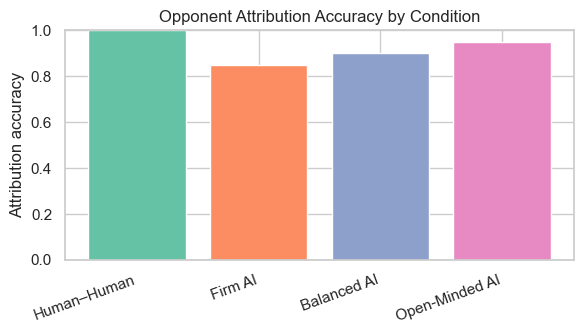


Moderation model (attribution × condition):
                                          Mixed Linear Model Regression Results
Model:                                 MixedLM                      Dependent Variable:                      delta_belief
No. Observations:                      434                          Method:                                  REML        
No. Groups:                            99                           Scale:                                   290.7499    
Min. group size:                       1                            Log-Likelihood:                          -1797.8875  
Max. group size:                       13                           Converged:                               Yes         
Mean group size:                       4.4                                                                               
-------------------------------------------------------------------------------------------------------------------------
                     

/Users/asherlim/dev/debate-platform/fyp-data/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
attr_col = "postDebateSurvey.player1OpponentPerception"
conf_col = "postDebateSurvey.player1PerceptionConfidence"

attr_df = debate_df[["debate_id", "condition", "n_rounds", "first_player_p1", attr_col, conf_col]].copy()
attr_df = attr_df.rename(columns={
    attr_col: "opponent_perception",
    conf_col: "perception_confidence",
})

is_ai_condition = attr_df["condition"] != "human-human"
attr_df["correct_attribution"] = np.where(
    is_ai_condition,
    attr_df["opponent_perception"].str.lower() == "ai",
    attr_df["opponent_perception"].str.lower() == "human",
)

print("Correct assumption of opponent identity by condition:")
acc = (
    attr_df.groupby("condition")["correct_attribution"]
    .agg(accuracy="mean", n="count")
    .reindex(CONDITION_ORDER)
    .round(2)
)
display(acc)

# Bar chart
fig, ax = plt.subplots(figsize=(6, 3.5))
palette = sns.color_palette("Set2", len(CONDITION_ORDER))
bars = ax.bar(
    [CONDITION_LABELS[c] for c in CONDITION_ORDER if c in acc.index],
    acc["accuracy"].values,
    color=palette,
)
ax.set_ylabel("Correct assumption rate")
ax.set_ylim(0, 1)
ax.set_title("Opponent Identity Assumption\n(correct identification rate by condition)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "attribution_accuracy.png", dpi=150)
plt.show()

# Moderation: add correct_attribution as interaction term.
# n_rounds_c and first_player_p1 are added as covariates - same rationale as LME:
# debate length and who opened are confounders independent of condition.
if HAS_STATSMODELS and lme_result is not None:
    lme_mod_df = lme_df.merge(
        attr_df[["debate_id", "correct_attribution"]],
        on="debate_id", how="left",
    ).dropna(subset=["correct_attribution"])

    mod_formula = (
        "delta_belief ~ C(condition, Treatment('human-human')) * round_c"
        " + n_rounds_c"
        " + first_player_p1"
        " + C(topic_id)"
        " + correct_attribution"
        " + correct_attribution:C(condition, Treatment('human-human'))"
    )
    mod_model  = smf.mixedlm(
        mod_formula, data=lme_mod_df, groups=lme_mod_df["participant_id"],
    )
    mod_result = mod_model.fit(reml=True, method="lbfgs")
    print("\nModeration model (attribution x condition):")
    print(mod_result.summary())

## 12. Mediation Analysis

Test whether reflection score mediates the relationship between AI argument quality and belief change using a bootstrapped indirect-effects framework (Baron & Kenny steps + Sobel / percentile-bootstrap CI).

> **Why test mediation?** The central theoretical question is *how* AI arguments cause belief change — via a *direct* quality-to-belief pathway, or via an *elaboration* pathway where good arguments prompt deeper reflection, and deeper reflection drives change. Mediation analysis decomposes the total effect into direct and indirect (via reflection) components, directly testing the elaboration mechanism.
>
> **Why use |Δbelief| for the bivariate screen?** In the correlation screen, a participant who is pushed strongly toward the AI's position and one who is pushed strongly away both show large absolute change. Signed Δbelief would cancel these out in a group mean but |Δbelief| captures overall responsiveness to argument quality regardless of direction — the appropriate preliminary screen before the signed directional mediation test.


In [8]:
from scipy import stats as sp_stats

# Aggregate player1 reflections per debate × round
ref_p1 = (
    ref_df[ref_df["player"] == "player1"]
    .groupby(["debate_id", "round"])
    .agg(
        reflection_length=("reflection_length", "mean"),
        reflection_quality=("reflection_quality", "mean"),
        acknowledged=("acknowledged", "max"),
    )
    .reset_index()
)

# Use quality score as mediator if GPT-4o mini scored; otherwise fall back to word count
MEDIATOR = (
    "reflection_quality"
    if ref_p1["reflection_quality"].notna().any()
    else "reflection_length"
)
print(f"Reflection mediator: {MEDIATOR}")

bh_with_ref = bh_analysis.merge(ref_p1, on=["debate_id", "round"], how="left")

# Merge debate-level covariates needed for mediation path models
bh_with_ref = bh_with_ref.merge(
    debate_df[["debate_id", "n_rounds", "first_player_p1"]],
    on="debate_id", how="left",
)
bh_with_ref["n_rounds_c"] = bh_with_ref["n_rounds"] - bh_with_ref["n_rounds"].mean()

valid_ref = bh_with_ref.dropna(subset=["delta_belief", MEDIATOR])

# Bivariate screen
r_val, p_val = sp_stats.pearsonr(
    valid_ref[MEDIATOR], valid_ref["delta_belief"].abs()
)
print(f"Pearson r({MEDIATOR}, |Δbelief|) = {r_val:.3f}  p = {p_val:.4f}")

# Report length correlation for comparison when quality scores are active
if MEDIATOR != "reflection_length":
    valid_len = bh_with_ref.dropna(subset=["delta_belief", "reflection_length"])
    r_len, p_len = sp_stats.pearsonr(
        valid_len["reflection_length"], valid_len["delta_belief"].abs()
    )
    print(f"Pearson r(reflection_length, |Δbelief|) = {r_len:.3f}  p = {p_len:.4f}  (word count, for comparison)")

# Mediation paths (requires statsmodels)
# n_rounds_c and first_player_p1 are included as covariates in both path models —
# debate length and who opened are confounders that could independently drive both
# reflection quality and belief change.
if HAS_STATSMODELS:
    valid_ref = valid_ref.copy()
    valid_ref["round_c"] = valid_ref["round"] - valid_ref["round"].mean()

    # Path a: condition → reflection quality (controlling for debate length + first player)
    path_a = smf.mixedlm(
        f"{MEDIATOR} ~ C(condition, Treatment('human-human')) + n_rounds_c + first_player_p1",
        data=valid_ref,
        groups=valid_ref["debate_id"],
    ).fit(reml=True, method="lbfgs")

    # Paths b + c′: reflection quality + condition → Δbelief (controlling for length + first player)
    path_bc = smf.mixedlm(
        f"delta_belief ~ C(condition, Treatment('human-human')) + {MEDIATOR}"
        " + n_rounds_c + first_player_p1",
        data=valid_ref,
        groups=valid_ref["debate_id"],
    ).fit(reml=True, method="lbfgs")

    print(f"\n--- Path a: condition → {MEDIATOR} ---")
    print(path_a.summary().tables[1])
    print(f"\n--- Paths b + c: condition + {MEDIATOR} → Δbelief ---")
    print(path_bc.summary().tables[1])

NameError: name 'ref_df' is not defined

## 13. ML Feature Construction (Core + Staged Exploratory Blocks)

Aggregate `bh_analysis` and `arg_df` to produce `ml_df` - one row per participant x round with core predictor columns and the target (`delta_belief`). `condition` is encoded numerically as `condition_enc`.

This section supports a **review-first exploratory workflow**:
1. Build `ml_df` with core approved features.
2. Compute exploratory blocks in a separate candidate table.
3. Print diagnostics and block-level previews.
4. Only merge selected blocks into training features after manual approval flags are turned on.

Exploratory blocks covered here:
- Belief dynamics (lag/rolling/cumulative movement)
- Relative argument advantage (own vs opponent gaps/ratios)
- Baseline-normalized belief geometry (distance to baseline/neutral/extremes)
- Linguistic style signals (hedging/certainty/negation/readability proxies)
- Reflection fidelity proxies (paraphrase vs opponent argument overlap/compression)
- GPT semantic reflection fidelity (faithfulness/coverage/charity)

Overlap note (intentional): lexical reflection-fidelity proxies and GPT semantic reflection-fidelity features measure related constructs at different levels of abstraction. Both are kept for ablation and robustness checks; only selected blocks should be activated in `BLOCKS_TO_APPLY`.

Feature-design rationale (kept as specified):

- **Why a strict no-leakage rule?** Features that can only be computed *using* the outcome at prediction time will inflate apparent model performance. Every feature is restricted to information available before or within that round that does not directly encode the belief trajectory endpoints.
- **Why `n_rounds` as a feature?** ~95% of debates end by mutual consent, so the number of rounds completed varies widely (3-14). A participant in a 14-round debate has received far more persuasion exposure than one in a 3-round debate. Without `n_rounds` the model cannot distinguish "this person barely changed because the debate was short" from "this person barely changed because they were resistant". It is present in every statistical model for the same reason.
- **Why `first_player_p1` as a feature?** Who speaks first may confer a primacy or anchoring advantage. The balanced condition has a 3:1 imbalance in first-player assignment, making it a meaningful confounder if excluded.
- **Why are within-round reflections, confidence, and influence legitimate predictors rather than leakage?** Within a round the event order is: (1) the participant reads the opponent's argument; (2) they write their reflection/acknowledgement; (3) they then record their updated belief value, confidence, and perceived influence. Reflections are therefore causally *upstream* of the belief recording - they are not derived from delta belief and are available without knowing the round's outcome. Leakage would only arise from using round r+1 features to predict round r change; all features here are restricted to round <= r.
- **Why `has_reflection` indicator rather than dropping reflection features?** In AI conditions, player2 (the AI) had no reflection task, so `reflection_quality` is structurally absent - not a missing value. Imputing 0 would conflate "no task" with "poor quality reflection". A binary `has_reflection` flag lets the model learn that absence is structural; the reflection quality columns are then median-imputed as usual for rows that do have reflections but are missing scores for other reasons.
- **Why `presurvey_enc` uses player1's survey only?** `preDebateSurvey.player2` is a valid self-report only in human-human debates (~21 debates, ~25% of rows). In all AI conditions it encodes the AI's assigned personality - a completely different quantity. Even for the human-human subset, player2 pre-survey is nearly collinear with `condition_enc` (non-null *if and only if* condition=human-human AND player=player2), meaning it carries almost no independent signal. It is dropped entirely.
- **Why median imputation for remaining NaN columns?** Dropping rows with missing NLP scores would introduce non-random missingness bias. Median imputation preserves all rows and is robust to skew.
- **(kept when structurally relevant)** If reflection fields are structurally absent for some rows, a binary indicator distinguishes "no task" from "low score" and prevents conflation during imputation.

 > **No-leakage rule summary:** all derived predictors are computed from information available at or before round `r` only.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# ---------------- CORE MODEL BUILD (DEFAULT TRAINING PATH) ----------------
# This cell defines the core (baseline) feature set and creates ml_df.
# Any exploratory features are added only in the next cell behind a review gate.
# --------------------------------------------------------------------------

# Per-round argument features keyed by debate_id x round x player role.
arg_by_role = (
    arg_df.groupby(["debate_id", "round", "arg_player_role"])
    .agg(
        arg_length=("arg_length", "mean"),
        arg_quality=("arg_quality", "mean"),
    )
    .reset_index()
)

own_args = arg_by_role.rename(columns={
    "arg_player_role": "player",
    "arg_length": "own_arg_length",
    "arg_quality": "own_arg_quality",
})

opponent_args = arg_by_role.copy()
opponent_args["player"] = np.where(
    opponent_args["arg_player_role"] == "player1", "player2", "player1"
)
opponent_args = opponent_args.rename(columns={
    "arg_length": "opponent_arg_length",
    "arg_quality": "opponent_arg_quality",
})[["debate_id", "round", "player", "opponent_arg_length", "opponent_arg_quality"]]

# Reflection features by player role.
ref_for_ml = (
    ref_df.groupby(["debate_id", "round", "player"])
    .agg(
        reflection_length=("reflection_length", "mean"),
        reflection_quality=("reflection_quality", "mean"),
        acknowledged=("acknowledged", "max"),
    )
    .reset_index()
)

# Base: all human per-round belief rows (rounds 1+).
# bh_analysis includes player1 for all conditions + player2 for human-human.
# preDebateSurvey.player1 is used for all rows.
# preDebateSurvey.player2 is dropped: valid only in human-human (~21 debates),
# nearly collinear with condition_enc, and adds negligible independent signal.
ml_base = bh_analysis.merge(
    debate_df[[
        "debate_id", "condition", "topic_id",
        "n_rounds", "first_player_p1",
        "preDebateSurvey.player1",
    ]],
    on=["debate_id", "condition"],
    how="left",
)

# presurvey_raw uses player1's self-report only.
# preDebateSurvey.player2 is a real self-report only in human-human debates;
# in AI conditions it encodes the AI's assigned personality — a different quantity.
# With only ~21 non-null values (human-human player2 rows only) and full collinearity
# with condition_enc, it adds negligible independent signal and is dropped.
ml_base["presurvey_raw"] = ml_base["preDebateSurvey.player1"]

ml_base = (
    ml_base
    .merge(own_args, on=["debate_id", "round", "player"], how="left")
    .merge(opponent_args, on=["debate_id", "round", "player"], how="left")
    .merge(ref_for_ml, on=["debate_id", "round", "player"], how="left")
)

# has_reflection: 1 if this participant had a reflection task and data was captured.
# Using a binary indicator rather than imputing 0 avoids conflating
# "no reflection task" with "low reflection quality".
ml_base["has_reflection"] = ml_base["reflection_quality"].notna().astype(int)

# Encode categoricals
le_cond = LabelEncoder().fit(CONDITION_ORDER)
le_stance = LabelEncoder().fit(["for", "against", "unsure"])
ml_base["condition_enc"] = le_cond.transform(
    ml_base["condition"].fillna("human-human")
)
ml_base["stance_enc"] = le_stance.transform(
    ml_base["stance_choice"].fillna("unsure")
)
ml_base["acknowledged"] = ml_base["acknowledged"].astype(float)

# Ordinal-encode pre-debate stance firmness (raw string → numeric).
# open_to_change < convinced_of_stance < firm_on_stance
_presurvey_map = {"open_to_change": 0, "convinced_of_stance": 1, "firm_on_stance": 2}
ml_base["presurvey_enc"] = (
    ml_base["presurvey_raw"].map(_presurvey_map).fillna(0).astype(int)
)

# ---------------- CORE MODEL FEATURES (USED BY DEFAULT) ----------------
FEATURE_COLS = [
    "round", "condition_enc", "topic_id", "stance_enc",
    "n_rounds",          # debate length — must control; varies 3–14 by mutual consent
    "first_player_p1",   # who opened — primacy confounder; 3:1 in balanced condition
    "confidence", "influence",
    "own_arg_length", "own_arg_quality",
    "opponent_arg_length", "opponent_arg_quality",
    "has_reflection", #structural indicator: 1=has reflection, 0=no reflection
    "reflection_length", "reflection_quality", "acknowledged",
    "presurvey_enc",
]
TARGET = "delta_belief"

feat_cols = [c for c in FEATURE_COLS if c in ml_base.columns]
ml_df = ml_base[["debate_id", "player"] + feat_cols + [TARGET]].dropna(subset=[TARGET]).copy()

# Impute remaining NaNs with column medians AFTER has_reflection is set.
# This means reflection_quality NaNs are imputed to median,
# but has_reflection=0 flags structurally absent reflections.
ml_df[feat_cols] = ml_df[feat_cols].fillna(ml_df[feat_cols].median(numeric_only=True))

print(f"ML DataFrame (core): {ml_df.shape[0]} rows x {len(feat_cols)} features")
print(f"Core feature columns: {feat_cols}")
print("\nCore has_reflection distribution:")
print(ml_df.groupby(["condition_enc", "has_reflection"]).size().to_string())
display(ml_df.head(3))

In [ ]:
# ---------------------------------------------------------------------------
# EXPLORATORY FEATURE BLOCKS (REVIEW FIRST, NOT CORE BY DEFAULT)
# These features are computed in a separate table and only appended to core
# features when the review gate below is explicitly enabled.
# ---------------------------------------------------------------------------
import re
import json
import hashlib

# Local stopword set to avoid extra sklearn dependency in this exploratory block.
STOP_WORDS = {
    "a", "an", "and", "are", "as", "at", "be", "but", "by", "for", "from", "if",
    "in", "into", "is", "it", "its", "of", "on", "or", "that", "the", "their",
    "then", "there", "these", "they", "this", "to", "was", "were", "will", "with",
}

def _tokenize_simple(text: str) -> list:
    if not isinstance(text, str):
        return []
    toks = re.findall(r"[a-zA-Z']+", text.lower())
    return [t for t in toks if t and t not in STOP_WORDS]

def _safe_ratio(a, b, eps=1e-6):
    return a / (b + eps)

def _jaccard_overlap(a: str, b: str) -> float:
    sa, sb = set(_tokenize_simple(a)), set(_tokenize_simple(b))
    if not sa and not sb:
        return np.nan
    return len(sa & sb) / max(len(sa | sb), 1)

def _style_features(text: str) -> dict:
    toks = _tokenize_simple(text)
    n_tok = len(toks)
    if n_tok == 0:
        return {
            "arg_hedge_density": np.nan,
            "arg_certainty_density": np.nan,
            "arg_negation_density": np.nan,
            "arg_lexical_diversity": np.nan,
            "arg_avg_sentence_len": np.nan,
        }

    hedge = {"maybe", "might", "could", "perhaps", "possibly", "likely", "arguably"}
    certainty = {"clearly", "definitely", "certainly", "always", "undeniably", "must"}
    negation = {"not", "never", "no", "none", "cannot", "can't", "won't", "isn't", "doesn't"}

    sentence_count = max(1, len(re.findall(r"[.!?]+", text or "")))
    return {
        "arg_hedge_density": sum(t in hedge for t in toks) / n_tok,
        "arg_certainty_density": sum(t in certainty for t in toks) / n_tok,
        "arg_negation_density": sum(t in negation for t in toks) / n_tok,
        "arg_lexical_diversity": len(set(toks)) / n_tok,
        "arg_avg_sentence_len": n_tok / sentence_count,
    }

ml_explore = ml_base.copy()

# Belief dynamics: add round-0 baseline belief per participant.
baseline_round0 = (
    bh_p1[bh_p1["round"] == 0][["debate_id", "player", "belief_value"]]
    .rename(columns={"belief_value": "belief_round0"})
)
ml_explore = ml_explore.merge(baseline_round0, on=["debate_id", "player"], how="left")

# Add participant and opponent argument text for reflection/style features.
arg_text_map = arg_df[["debate_id", "round", "arg_player_role", "text"]].copy()

own_text = arg_text_map.rename(columns={
    "arg_player_role": "player",
    "text": "participant_arg_text",
})[["debate_id", "round", "player", "participant_arg_text"]]
ml_explore = ml_explore.merge(own_text, on=["debate_id", "round", "player"], how="left")

opp_text = arg_text_map.copy()
opp_text["player"] = np.where(opp_text["arg_player_role"] == "player1", "player2", "player1")
opp_text = opp_text.rename(columns={"text": "opponent_arg_text"})[["debate_id", "round", "player", "opponent_arg_text"]]
ml_explore = ml_explore.merge(opp_text, on=["debate_id", "round", "player"], how="left")

# Add round-aligned reflection text for reflection-fidelity features.
ref_text = ref_df[["debate_id", "round", "player", "paraphrase"]].rename(
    columns={"paraphrase": "reflection_text"}
)
ml_explore = ml_explore.merge(ref_text, on=["debate_id", "round", "player"], how="left")

ml_explore = ml_explore.sort_values(["debate_id", "player", "round"]).copy()
g = ml_explore.groupby(["debate_id", "player"], group_keys=False)

# Belief dynamics (strictly prior rounds only via shift).
ml_explore["delta_lag1"] = g["delta_belief"].shift(1)
ml_explore["delta_roll2_mean"] = g["delta_belief"].transform(
    lambda s: s.shift(1).rolling(2, min_periods=1).mean()
)
ml_explore["cum_abs_delta_prior"] = g["delta_belief"].transform(lambda s: s.shift(1).abs().cumsum())

# Relative argument advantage (own vs opponent).
ml_explore["quality_gap_own_minus_opponent"] = ml_explore["own_arg_quality"] - ml_explore["opponent_arg_quality"]
ml_explore["length_gap_own_minus_opponent"] = ml_explore["own_arg_length"] - ml_explore["opponent_arg_length"]
ml_explore["quality_ratio_own_over_opponent"] = _safe_ratio(
    ml_explore["own_arg_quality"], ml_explore["opponent_arg_quality"]
)
ml_explore["length_ratio_own_over_opponent"] = _safe_ratio(
    ml_explore["own_arg_length"], ml_explore["opponent_arg_length"]
)

# Baseline-normalized belief geometry.
ml_explore["belief_from_start"] = ml_explore["belief_value"] - ml_explore["belief_round0"]
ml_explore["dist_to_neutral"] = (ml_explore["belief_value"] - 50).abs()
ml_explore["dist_to_extreme"] = np.minimum(
    ml_explore["belief_value"].abs(),
    (100 - ml_explore["belief_value"]).abs(),
)

# Reflection fidelity proxies (lexical, cheap baseline).
ml_explore["reflection_token_overlap"] = [
    _jaccard_overlap(r, o)
    for r, o in zip(ml_explore["reflection_text"], ml_explore["opponent_arg_text"])
]
ml_explore["reflection_compression_ratio"] = [
    _safe_ratio(len(_tokenize_simple(r)), len(_tokenize_simple(o)))
    for r, o in zip(ml_explore["reflection_text"], ml_explore["opponent_arg_text"])
]

# Argument style signals.
style_df = ml_explore["participant_arg_text"].apply(_style_features).apply(pd.Series)
ml_explore = pd.concat([ml_explore, style_df], axis=1)

# Optional GPT semantic reflection-fidelity features for exploratory-only use.
# Intentional overlap: this semantic block complements lexical reflection proxies.
USE_GPT_SEMANTIC_EXPLORATION = True

_HAS_GPT = bool(globals().get("HAS_OPENAI", False) and globals().get("_client") is not None)
_CACHE = globals().get("_score_cache", {})

_REF_SEMANTIC_SYSTEM = """
You are a strict, neutral evaluator of reflection fidelity in a debate.
Given the original opponent argument and a participant reflection, score each dimension from 1 to 5.

Dimensions:
- faithfulness: does the reflection preserve the original meaning and claims?
- coverage: does the reflection include key points rather than only fragments?
- charity: does the reflection represent the opponent fairly (not strawman/distort)?
- overall: holistic reflection fidelity quality.

Return only JSON with exactly this schema:
{"faithfulness": <int>, "coverage": <int>, "charity": <int>, "overall": <int>}
""".strip()

def _llm_score_cached(prompt: str, system: str, kind: str, keys: list) -> dict:
    out = {k: float("nan") for k in keys}
    if not isinstance(prompt, str) or not prompt.strip() or not _HAS_GPT:
        return out
    cache_key = hashlib.md5(f"{kind}:{prompt}".encode()).hexdigest()
    if cache_key in _CACHE and isinstance(_CACHE[cache_key], dict):
        cached = _CACHE[cache_key]
        return {k: float(cached.get(k, float("nan"))) for k in keys}
    try:
        resp = _client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system},
                {"role": "user", "content": prompt},
            ],
            temperature=0,
            max_tokens=80,
        )
        parsed = json.loads(resp.choices[0].message.content)
        result = {k: float(parsed.get(k, float("nan"))) for k in keys}
        _CACHE[cache_key] = result
        if callable(globals().get("_update_cost")):
            _update_cost(resp.usage)
        return result
    except Exception:
        return out

if USE_GPT_SEMANTIC_EXPLORATION and _HAS_GPT:
    print("Scoring GPT semantic reflection features with gpt-4o-mini...")
    ref_rows = []
    ref_keys = ["faithfulness", "coverage", "charity", "overall"]
    for _, row in ml_explore.iterrows():
        opp = str(row.get("opponent_arg_text", "") or "")[:500]
        ref = str(row.get("reflection_text", "") or "")[:500]
        prompt = (
            f"Original opponent argument:\n{opp}\n\n"
            f"Participant reflection:\n{ref}"
        )
        ref_rows.append(_llm_score_cached(prompt, _REF_SEMANTIC_SYSTEM, "exp_ref_semantic", ref_keys))
    ref_sem = pd.DataFrame(ref_rows, index=ml_explore.index)
    ml_explore["gpt_reflection_faithfulness"] = ref_sem["faithfulness"]
    ml_explore["gpt_reflection_coverage"] = ref_sem["coverage"]
    ml_explore["gpt_reflection_charity"] = ref_sem["charity"]
    ml_explore["gpt_reflection_semantic"] = ref_sem["overall"]

    if "_SCORE_CACHE_PATH" in globals():
        try:
            _SCORE_CACHE_PATH.write_text(json.dumps(_CACHE))
        except Exception:
            pass
else:
    print("GPT semantic reflection scoring skipped (OpenAI client unavailable or disabled).")

BLOCK_FEATURES = {
    "belief_dynamics": ["delta_lag1", "delta_roll2_mean", "cum_abs_delta_prior"],
    "relative_argument_advantage": [
        "quality_gap_own_minus_opponent",
        "length_gap_own_minus_opponent",
        "quality_ratio_own_over_opponent",
        "length_ratio_own_over_opponent",
    ],
    "baseline_belief_geometry": [
        "belief_from_start", "dist_to_neutral", "dist_to_extreme",
    ],
    "reflection_fidelity": [
        "reflection_token_overlap", "reflection_compression_ratio",
    ],
    "argument_style_signals": [
        "arg_hedge_density",
        "arg_certainty_density",
        "arg_negation_density",
        "arg_lexical_diversity",
        "arg_avg_sentence_len",
    ],
    "gpt_reflection_semantics": [
        "gpt_reflection_faithfulness",
        "gpt_reflection_coverage",
        "gpt_reflection_charity",
        "gpt_reflection_semantic",
    ],
}

# ---- Review gate (default: keep core model unchanged) ----
BLOCKS_TO_APPLY = []  # Example: ["belief_dynamics", "gpt_reflection_semantics"]
CONFIRM_APPLY_BLOCKS = False

# Print block-level diagnostics for review
diag_rows = []
for block, cols in BLOCK_FEATURES.items():
    valid_cols = [c for c in cols if c in ml_explore.columns]
    miss_rate = ml_explore[valid_cols].isna().mean().mean() if valid_cols else np.nan
    diag_rows.append({
        "block": block,
        "n_features": len(valid_cols),
        "avg_missing_rate": round(float(miss_rate), 4) if pd.notna(miss_rate) else np.nan,
    })

diag_df = pd.DataFrame(diag_rows).sort_values("block").reset_index(drop=True)
print("Exploratory blocks ready for review (not applied to training features yet):")
display(diag_df)

preview_cols = [
    "debate_id", "player", "round", "delta_belief",
    "delta_lag1", "quality_gap_own_minus_opponent",
    "belief_from_start", "reflection_token_overlap", "arg_hedge_density",
    "gpt_reflection_semantic",
]
preview_cols = [c for c in preview_cols if c in ml_explore.columns]
display(ml_explore[preview_cols].head(8))

if BLOCKS_TO_APPLY and CONFIRM_APPLY_BLOCKS:
    add_cols = []
    for b in BLOCKS_TO_APPLY:
        add_cols.extend([c for c in BLOCK_FEATURES.get(b, []) if c in ml_explore.columns])
    add_cols = [c for c in add_cols if c not in feat_cols]

    feat_cols = feat_cols + add_cols
    ml_df = ml_explore[["debate_id", "player"] + feat_cols + [TARGET]].dropna(subset=[TARGET]).copy()
    ml_df[feat_cols] = ml_df[feat_cols].fillna(ml_df[feat_cols].median(numeric_only=True))

    print(f"Applied blocks: {BLOCKS_TO_APPLY}")
    print(f"Updated feature count: {len(feat_cols)}")
else:
    print("\nReview gate active: exploratory blocks were computed but NOT added to feat_cols/ml_df.")
    print("Set BLOCKS_TO_APPLY and CONFIRM_APPLY_BLOCKS=True after your review.")

## 14. ML Models

Train and evaluate two model families for each target:

| Target | Models |
|---|---|
| `delta_belief` per round (continuous) | ElasticNetCV · XGBRegressor |
| `flip_label` (binary stance change) | LogisticRegressionCV · XGBClassifier |

 > **Why two model families?** ElasticNet / LogisticRegressionCV are linear models with L1+L2 regularisation - they are interpretable, have low variance, and serve as a strong baseline that also performs automatic feature selection. XGBoost is a non-linear ensemble that captures interactions and non-monotonicities the linear model cannot. Comparing the two quantifies how much non-linearity is present in the data and whether the added complexity is justified.
 >
 > **Why GroupKFold by `debate_id`?** Multiple rounds from the same debate are not independent observations - they share the same participants, topic, and condition. Standard k-fold would allow the model to "see" rounds from the same debate in both train and test, artificially inflating generalisation estimates. `GroupKFold` with `groups=debate_id` ensures all rounds of a given debate appear in only one fold, giving an honest estimate of out-of-debate generalisation.
 >
 > **Why class balancing for the flip classifier?** Stance flips are relatively rare (approximately 20-30% of participants). Without balancing, a classifier that always predicts "no flip" achieves high accuracy while providing no useful signal. `class_weight='balanced'` (LogisticRegressionCV) and `scale_pos_weight` (XGBoost) reweight the minority class to penalise false negatives more heavily. AUC-ROC and F1 are reported alongside accuracy as metrics that are insensitive to class imbalance.

In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X      = ml_df[feat_cols].values
y      = ml_df[TARGET].values
groups = ml_df["debate_id"].values

gkf = GroupKFold(n_splits=5)

# --- Elastic Net ---
enet_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9, 1.0],
        cv=3,
        max_iter=5000,
        random_state=42,
    )),
])

enet_preds, enet_true = [], []
for train_idx, test_idx in gkf.split(X, y, groups):
    enet_pipe.fit(X[train_idx], y[train_idx])
    enet_preds.extend(enet_pipe.predict(X[test_idx]))
    enet_true.extend(y[test_idx])

enet_rmse = root_mean_squared_error(enet_true, enet_preds)
enet_r2   = r2_score(enet_true, enet_preds)
print(f"Elastic Net  | RMSE: {enet_rmse:.3f}  R²: {enet_r2:.3f}")

# Fit on full data to inspect coefficients
enet_pipe.fit(X, y)
coefs = (
    pd.Series(enet_pipe.named_steps["model"].coef_, index=feat_cols)
    .sort_values(key=abs, ascending=False)
)
print("\nElastic Net coefficients (standardised inputs):")
display(coefs.to_frame("coef").round(4))

In [ ]:
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed — skipping.\nInstall with: pip install xgboost")

if HAS_XGB:
    xgb_model = xgb.XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )

    xgb_preds, xgb_true = [], []
    for train_idx, test_idx in gkf.split(X, y, groups):
        xgb_model.fit(X[train_idx], y[train_idx])
        xgb_preds.extend(xgb_model.predict(X[test_idx]))
        xgb_true.extend(y[test_idx])

    xgb_rmse = root_mean_squared_error(xgb_true, xgb_preds)
    xgb_r2   = r2_score(xgb_true, xgb_preds)
    print(f"XGBoost      | RMSE: {xgb_rmse:.3f}  R²: {xgb_r2:.3f}")

    # Feature importance (gain)
    xgb_model.fit(X, y)
    fi = (
        pd.Series(xgb_model.feature_importances_, index=feat_cols)
        .sort_values(ascending=False)
    )
    fig, ax = plt.subplots(figsize=(6, 4))
    fi.plot(kind="barh", ax=ax, color=sns.color_palette("Set2"))
    ax.invert_yaxis()
    ax.set_xlabel("Importance (gain)")
    ax.set_title("XGBoost Feature Importances")
    plt.tight_layout()
    plt.savefig(output_dir / "xgb_feature_importance.png", dpi=150)
    plt.show()

# Model comparison summary
print("\n--- Model Comparison ---")
comparison_data = {"RMSE": [enet_rmse], "R²": [enet_r2]}
comparison_idx  = ["Elastic Net"]
if HAS_XGB:
    comparison_data["RMSE"].append(xgb_rmse)
    comparison_data["R²"].append(xgb_r2)
    comparison_idx.append("XGBoost")
display(pd.DataFrame(comparison_data, index=comparison_idx).round(4))

In [ ]:
# ── 13.3 Stance Flip Classifier (debate-level) ───────────────────────────────
# Aggregate per-round features to debate level, then classify flip_label.
# Small n (~90 debates after merge) — interpret directionally.

from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, f1_score

# Debate-level feature matrix: mean of per-round features per debate
ml_debate = (
    ml_df[["debate_id"] + feat_cols]
    .groupby("debate_id")
    .mean()
    .reset_index()
)
ml_debate = ml_debate.merge(
    flip_df[["debate_id", "flip_label"]].dropna(subset=["flip_label"]),
    on="debate_id", how="inner",
)

X_cls    = ml_debate[feat_cols].values
y_cls    = ml_debate["flip_label"].values.astype(int)
grps_cls = ml_debate["debate_id"].values

n_splits_cls = min(5, ml_debate["debate_id"].nunique() // 2)
gkf_cls = GroupKFold(n_splits=max(2, n_splits_cls))

print(f"Classifier dataset: {len(ml_debate)} debates  |  "
      f"flip rate: {y_cls.mean():.1%}  |  folds: {max(2, n_splits_cls)}")

# --- Logistic Regression (with class balancing) ---
log_proba, log_label, log_true = [], [], []
for tr, te in gkf_cls.split(X_cls, y_cls, grps_cls):
    sc = StandardScaler().fit(X_cls[tr])
    lr = LogisticRegressionCV(
        cv=3, max_iter=1000, class_weight="balanced", random_state=42,
    )
    lr.fit(sc.transform(X_cls[tr]), y_cls[tr])
    log_proba.extend(lr.predict_proba(sc.transform(X_cls[te]))[:, 1])
    log_label.extend(lr.predict(sc.transform(X_cls[te])))
    log_true.extend(y_cls[te])

log_auc = roc_auc_score(log_true, log_proba)
log_f1  = f1_score(log_true, log_label, zero_division=0)
print(f"Logistic Regression  | AUC: {log_auc:.3f}  F1: {log_f1:.3f}")

# --- XGBoost Classifier ---
if HAS_XGB:
    xgb_cls = xgb.XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_cls == 0).sum() / max((y_cls == 1).sum(), 1),
        random_state=42, n_jobs=-1, eval_metric="logloss",
    )
    xgb_cls_proba, xgb_cls_label, xgb_cls_true = [], [], []
    for tr, te in gkf_cls.split(X_cls, y_cls, grps_cls):
        xgb_cls.fit(X_cls[tr], y_cls[tr])
        xgb_cls_proba.extend(xgb_cls.predict_proba(X_cls[te])[:, 1])
        xgb_cls_label.extend(xgb_cls.predict(X_cls[te]))
        xgb_cls_true.extend(y_cls[te])

    xgb_cls_auc = roc_auc_score(xgb_cls_true, xgb_cls_proba)
    xgb_cls_f1  = f1_score(xgb_cls_true, xgb_cls_label, zero_division=0)
    print(f"XGBoost Classifier   | AUC: {xgb_cls_auc:.3f}  F1: {xgb_cls_f1:.3f}")

# Classifier comparison summary
print("\n--- Classifier Comparison (Stance Flip, debate-level) ---")
cls_idx  = ["Logistic Regression"]
cls_data = {"AUC": [log_auc], "F1": [log_f1]}
if HAS_XGB:
    cls_idx.append("XGBoost Classifier")
    cls_data["AUC"].append(xgb_cls_auc)
    cls_data["F1"].append(xgb_cls_f1)
display(pd.DataFrame(cls_data, index=cls_idx).round(4))
print("\n  Note: n≈90 debates — interpret directionally; AUC may be unstable across folds.")


In [ ]:
# --- Export all processed DataFrames ---
debate_df.to_csv(output_dir / "debates.csv", index=False)
debate_df.to_json(output_dir / "debates.json", orient="records", force_ascii=False)

bh_p1.to_csv(output_dir / "belief_history_p1.csv", index=False)
bh_analysis.to_csv(output_dir / "belief_analysis.csv", index=False)

arg_df.to_csv(output_dir / "arguments.csv", index=False)
ref_df.to_csv(output_dir / "reflections.csv", index=False)

ml_df.to_csv(output_dir / "ml_features.csv", index=False)

print(f"All files saved to: {output_dir}")
for f in sorted(output_dir.iterdir()):
    print(f"  {f.name}")